# CCS Techno-Economic Model — v7 (Corrected)
## Trehørningen Energisentral · Eidsiva Bioenergi AS

**Scenarios:** S1 Offshore solo · S2 Onshore solo · S3 Onshore hub  
**Reference currency:** 2025 NOK · **WACC:** 8% · **Lifetime:** 20 years  
**Version notes:** TEC→TOC multipliers corrected; reboiler duty wired into MC;
FOAK ramp-up levelised in LCOC denominator; CRN pairwise comparison;
S2 compression OPEX added; solvent baseline documented; all structural scenario sweeps added.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import beta as beta_dist, spearmanr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Imports complete")

Imports complete


## 2. Currency and Cost-Conversion Protocol (Chapter 5, §5.2)

All costs in **2025 NOK** unless stated otherwise.

| Parameter | Value | Source |
|---|---|---|
| EUR/NOK 2025 | 11.50 | ECB 2025 reference rate |
| USD/NOK 2025 | 10.56 | 2025 reference |
| CEPCI 2017 | 603 | Documented in project analytical framework |
| CEPCI 2023 | 800 | **Approximate** — no authoritative 2023 value in literature base; sensitivity is ~5% on TEC |
| CEPCI 2025 | 760 | Documented in project analytical framework |
| SSB CPI 2021 | 116.3 | Statistics Norway |
| SSB CPI 2025 | 143.0 | Statistics Norway |

In [2]:
# ── Currency and escalation constants ──────────────────────────────────────
EUR_NOK_2025 = 11.50
EUR_NOK_2023 = 11.48   # For truck rates (2023 source year; service cost, no CEPCI applied)
USD_NOK_2025 = 10.56
CEPCI_2017   = 603
CEPCI_2023   = 800    # APPROXIMATE — documented as such
CEPCI_2025   = 760
SSB_CPI_2021 = 116.3
SSB_CPI_2025 = 143.0

# Escalation factors
cepci_2017_to_2025 = CEPCI_2025 / CEPCI_2017   # 1.260
cepci_2023_to_2025 = CEPCI_2025 / CEPCI_2023   # 0.950 (approximate)
ssb_2021_to_2025   = SSB_CPI_2025 / SSB_CPI_2021  # 1.229

print(f"CEPCI 2017→2025: {cepci_2017_to_2025:.4f}")
print(f"CEPCI 2023→2025: {cepci_2023_to_2025:.4f}  [APPROXIMATE — ±5%]")
print(f"SSB CPI 2021→2025: {ssb_2021_to_2025:.4f}")

CEPCI 2017→2025: 1.2604
CEPCI 2023→2025: 0.9500  [APPROXIMATE — ±5%]
SSB CPI 2021→2025: 1.2296


## 3. Case Study Parameters (Chapter 5, §5.1)

In [3]:
# ── Design capacity scenarios (Table 5.1) ──────────────────────────────────
# Scenario A: right-sized at 50k t/yr
# Scenario B: right-sized at 70k t/yr (BASE CASE)
# Scenario C: 70k design, 50k actual (underutilisation risk)
DESIGN_SCENARIOS = {
    "A": {"Q_design": 50_000,  "Q_captured": 50_000},
    "B": {"Q_design": 70_000,  "Q_captured": 70_000},   # BASE
    "C": {"Q_design": 70_000,  "Q_captured": 50_000},   # CAPEX on 70k; throughput 50k
}
BASE_SCENARIO = "B"
Q_design_base   = DESIGN_SCENARIOS[BASE_SCENARIO]["Q_design"]    # 70,000 t/yr
Q_captured_base = DESIGN_SCENARIOS[BASE_SCENARIO]["Q_captured"]  # 70,000 t/yr

# ── CO2 concentration scenarios (Table 5.2) ────────────────────────────────
# 10 mol% base; 8% and 12% discrete alternates
x_CO2 = {"low": 0.08, "base": 0.10, "high": 0.12}
x_CO2_base = x_CO2["base"]

# ── Biogenic fraction scenarios (Table 5.3) ────────────────────────────────
# 65% base (Roussanaly et al. 2020); 50% alternate (Gabrielli et al. 2022)
phi_bio = {"base": 0.65, "alt": 0.50}
phi_bio_base = phi_bio["base"]

# ── Capture rate (fixed) ───────────────────────────────────────────────────
eta_cap = 0.90   # Universal across all sources

# ── Financial parameters ───────────────────────────────────────────────────
r_wacc = 0.08
n_life = 20
CRF = (r_wacc * (1 + r_wacc)**n_life) / ((1 + r_wacc)**n_life - 1)

# ── Operating hours: two-season model (§5.1.4) ────────────────────────────
hours_winter = 4380   # Oct–Mar
hours_summer = 4380   # Apr–Sep
CF_summer    = 1.00
CF_winter_central = 0.85   # Judgement-calibrated; MC range Uniform(0.80, 0.90)
CF_winter_lo = 0.80
CF_winter_hi = 0.90
t_op_central = hours_winter * CF_winter_central + hours_summer * CF_summer

print(f"CRF (8%, 20yr): {CRF:.5f}")
print(f"Central annual op. hours: {t_op_central:.0f} h/yr  (KAN ref: 8,000 h/yr)")
print(f"Design throughput base: {Q_design_base:,} t/yr")

CRF (8%, 20yr): 0.10185
Central annual op. hours: 8103 h/yr  (KAN ref: 8,000 h/yr)
Design throughput base: 70,000 t/yr


## 4. Flue Gas Flow Rate (Eq. 5.1, §5.1.2)

In [4]:
# ── CO2 density at standard conditions (0°C, 1 atm) ──────────────────────
M_CO2   = 44.01    # g/mol
V_molar = 22.414   # L/mol at STP
rho_CO2 = M_CO2 / V_molar   # = 1.9635 kg/Nm³

def flue_gas_flow_F(Q_captured_t_yr, x_CO2_frac, t_op_h_yr, cap_rate=0.90):
    """Eq. 5.1: F [10³ Nm³/h] from annual captured volume.
    Q_captured: t CO2/yr actually captured (not design)
    x_CO2_frac: mole fraction (decimal)
    """
    return (Q_captured_t_yr * 1000) / (
        t_op_h_yr * x_CO2_frac * rho_CO2 * cap_rate * 1000)

F_base = flue_gas_flow_F(Q_captured_base, x_CO2_base, t_op_central)
scale_t_hr_base = Q_captured_base / t_op_central   # t CO2/h

print(f"CO2 density at STP: {rho_CO2:.4f} kg/Nm³")
print(f"Flue gas flow (base): {F_base:.3f} × 10³ Nm³/h")
print(f"Capture scale (base): {scale_t_hr_base:.3f} t CO2/h")

CO2 density at STP: 1.9635 kg/Nm³
Flue gas flow (base): 48.885 × 10³ Nm³/h
Capture scale (base): 8.639 t CO2/h


## 5. Kim & Léonard (2025) Correlations (§5.4.2)

In [5]:
# ── Eq. 5.3: MEA capture TEC ──────────────────────────────────────────────
# TEC [M€2023] = α + (β·x_CO2^n + γ)·F^m
# x_CO2 must be a DECIMAL fraction (0.10 for 10 mol%)
kl = dict(alpha=2.1673, beta=0.8092, gamma=-0.00332, n=0.5291, m=0.8391)

def kim_leonard_TEC_MEur2023(x_CO2_frac, F_1000Nm3h):
    """Eq. 5.3: TEC [M€2023]. x_CO2_frac as decimal (0.10 for 10 mol%)."""
    return (kl["alpha"]
            + (kl["beta"] * x_CO2_frac**kl["n"] + kl["gamma"])
            * F_1000Nm3h**kl["m"])

# ── Eq. 5.4: Compression TEC (S2 only; 150 bar supercritical) ────────────
def kim_leonard_compression_TEC_per_t_hr(scale_t_hr):
    """Eq. 5.4: TEC_compression [M€2023 per t CO2/h]. S2 only."""
    return 0.3334 * scale_t_hr**(-0.503)

# ── Eq. 5.8: Electrical duty (scale-invariant) ────────────────────────────
def electrical_duty_kWh_t(x_CO2_frac):
    """Eq. 5.8: Capture plant electrical duty [kWh/t]."""
    return 10.420 * np.exp(-23.49 * x_CO2_frac) + 2.164 * np.exp(-1.235 * x_CO2_frac)

# ── Eq. 5.9: Cooling duty (for reference; not separately monetised) ────────
def cooling_duty_GJ_t(x_CO2_frac):
    """Eq. 5.9: Cooling duty [GJ/t]. Retained for cross-validation; bundled in fixed O&M."""
    return 10.040 * np.exp(-33.73 * x_CO2_frac) + 2.905 * np.exp(0.2108 * x_CO2_frac)

TEC_base = kim_leonard_TEC_MEur2023(x_CO2_base, F_base)
e_elec   = electrical_duty_kWh_t(x_CO2_base)
e_cool   = cooling_duty_GJ_t(x_CO2_base)

print(f"TEC (base, M€2023):         {TEC_base:.3f}")
print(f"Electrical duty (10 mol%):  {e_elec:.2f} kWh/t")
print(f"Cooling duty (10 mol%):     {e_cool:.2f} GJ/t  [not separately monetised]")

# ── Eliasson/Energiforsk formula (§5.4.6) ────────────────────────────────
# CAPEX [k€2021] = 15,520 × (t CO2/hr)^0.6339  (Nordic-specific cross-check)
def eliasson_TIC_MEur2021(scale_t_hr):
    """Eliasson et al. (2021) via KAN (2025): Total Installed Cost [M€2021].
    Covers capture plant incl. compression; excludes tanks, land, groundworks.
    NOT carried through DOE/NETL chain — this IS a TIC estimate directly.
    """
    return 15_520 * scale_t_hr**0.6339 / 1000   # k€ → M€

TIC_eliasson_MEur2021 = eliasson_TIC_MEur2021(scale_t_hr_base)
# Escalate 2021→2025: CEPCI 722→760 (approx; 2021 CEPCI ~722)
CEPCI_2021 = 722
TIC_eliasson_MNOK2025 = (TIC_eliasson_MEur2021
                          * (CEPCI_2025 / CEPCI_2021)
                          * EUR_NOK_2025)
print(f"\nEliasson TIC (M€2021):  {TIC_eliasson_MEur2021:.1f}")
print(f"Eliasson TIC (MNOK2025): {TIC_eliasson_MNOK2025:.0f}  [Nordic lower-bound cross-check]")

TEC (base, M€2023):         8.337
Electrical duty (10 mol%):  2.91 kWh/t
Cooling duty (10 mol%):     3.31 GJ/t  [not separately monetised]

Eliasson TIC (M€2021):  60.9
Eliasson TIC (MNOK2025): 737  [Nordic lower-bound cross-check]


## 6. DOE/NETL Multiplier Chain: TEC → TOC (§5.4.3) — CORRECTED

Following Rubin (2012, Fig. 3b) and Rubin et al. (2013, Table 5).
Norway location factor 1.25 applied at BEC step (IEAGHG 2018 via Kim & Léonard 2025).

**Corrected multipliers** (previous version compounded incorrectly):
- Base: 1.85× TEC (in stated 1.7–1.9× range)
- FOAK: 2.50× TEC (in stated 2.3–2.5× range)

Contingencies applied as **additive percentages on EPC** (DOE/NETL convention):
- Base: process 5% + project 15% on EPC; owner costs 5% on TPC
- FOAK (Becattini et al., 2024): process 20% + system 10% + project 40% on EPC; no separate owner line

In [6]:
# ── DOE/NETL chain constants ──────────────────────────────────────────────
f_install    = 1.12   # Installation, supporting facilities (TEC→BEC before location)
f_loc_norway = 1.25   # Norway location factor (IEAGHG 2018 via Kim & Léonard 2025)
f_epc_srv    = 1.05   # EPC engineering/procurement services (BEC→EPC)

# Base case contingency
proc_cont_base = 0.05   # Process contingency (MEA is commercially mature; EPRI 1993)
proj_cont_base = 0.15   # Project contingency upper Class II (Rubin et al. 2013)
owner_base     = 0.05   # Owner costs, spares, initial inventory

# FOAK contingency (Becattini et al. 2024)
proc_cont_foak  = 0.20
sys_cont_foak   = 0.10
proj_cont_foak  = 0.40
# Owner costs absorbed into FOAK contingency loading (no separate owner line)

def tec_to_toc(TEC_MNOK, case="base", verbose=False):
    """
    DOE/NETL chain: TEC → BEC → EPC → TPC → TOC.
    Corrected to produce 1.85× (base) and 2.50× (FOAK) as per Chapter 5 Table 5.6.
    Contingencies applied as ADDITIVE percentages on EPC (Rubin et al. 2013 convention).
    """
    BEC = TEC_MNOK * f_install * f_loc_norway              # = 1.40 × TEC
    EPC = BEC * f_epc_srv                                  # = 1.47 × TEC

    if case == "base":
        TPC = EPC * (1 + proc_cont_base + proj_cont_base)  # = EPC × 1.20 = 1.764 × TEC
        TOC = TPC * (1 + owner_base)                        # = TPC × 1.05 = 1.852 × TEC
    elif case == "foak":
        # Becattini et al. (2024): additive contingency on EPC
        TPC = EPC * (1 + proc_cont_foak + sys_cont_foak + proj_cont_foak)  # = EPC × 1.70 = 2.499 × TEC
        TOC = TPC   # FOAK contingency absorbs owner costs
    else:
        raise ValueError(f"Unknown case: {case}")

    if verbose:
        mult = TOC / TEC_MNOK
        print(f"  BEC={BEC:.2f} EPC={EPC:.2f} TPC={TPC:.2f} TOC={TOC:.2f} MNOK")
        print(f"  TEC→TOC multiplier: {mult:.3f}×")
    return BEC, EPC, TPC, TOC

print("── Multiplier verification ──────────────────────────────────────────")
print("Base case (target 1.7–1.9×):")
_, _, _, TOC_check_base = tec_to_toc(100, "base", verbose=True)
print("FOAK case (target 2.3–2.5×):")
_, _, _, TOC_check_foak = tec_to_toc(100, "foak", verbose=True)

── Multiplier verification ──────────────────────────────────────────
Base case (target 1.7–1.9×):
  BEC=140.00 EPC=147.00 TPC=176.40 TOC=185.22 MNOK
  TEC→TOC multiplier: 1.852×
FOAK case (target 2.3–2.5×):
  BEC=140.00 EPC=147.00 TPC=249.90 TOC=249.90 MNOK
  TEC→TOC multiplier: 2.499×


## 7. CAPEX Scaling Exponent and Cost-Level Uncertainty (§5.4.6)

In [7]:
# ── Scaling exponent: f ~ Uniform(0.55, 0.75), central 0.65 (IEAGHG 2024) ─
f_scale_central = 0.65
f_scale_lo      = 0.55
f_scale_hi      = 0.75

def scale_capex(C_ref, Q_ref, Q_target, f=0.65):
    """Power-law scaling Eq. 5.6: C_B = C_A × (Q_B/Q_A)^f."""
    return C_ref * (Q_target / Q_ref) ** f

# ── Beta(2,3) cost-level multiplier ── ────────────────────────────────────
# Rescaled to [0.70, 1.50] → range −30%/+50% (Roussanaly et al. 2020)
def sample_beta_cost_mult(n, a=2, b=3, lo=0.70, hi=1.50):
    """Beta(2,3) rescaled to [0.70, 1.50]. Expected value ≈ 1.02 (slight upward skew)."""
    return lo + beta_dist.rvs(a, b, size=n) * (hi - lo)

# Verify expected value
ev = 0.70 + (2/(2+3)) * 0.80
print(f"Beta(2,3) expected multiplier: {ev:.3f}  (slightly above 1.0 — correct; literature shows upward skew)")

# ── Liquefaction CAPEX anchor (§5.6.1) ────────────────────────────────────
# Source: Returkraft Langemyr/Marvika port study via KAN (2025)
# NOK 100.1M (2021) inflated via SSB CPI to 2025
LIQ_REF_MNOK_2021 = 100.1
LIQ_REF_MNOK_2025 = LIQ_REF_MNOK_2021 * ssb_2021_to_2025   # = 123.1 MNOK
LIQ_REF_Q          = 100_000   # t/yr — Returkraft reference (KAN 2025, p.32)

print(f"\nLiquefaction CAPEX anchor: NOK {LIQ_REF_MNOK_2025:.1f}M (2025)")
print(f"Reference throughput: {LIQ_REF_Q:,} t/yr (Returkraft/KAN 2025)")

# ── Heat pump CAPEX (§5.1.5, Aspelund et al. 2022) ──────────────────────
# €200–500/kWth (Section 7.7.3) at 26–45 MW scale; extrapolated to ~4.8 MW
HP_CAPEX_EUR_kWth   = 500   # Upper end (conservative for smaller unit)
HP_OUTPUT_MW_100k   = 6.0   # Net heat output at 100k t/yr reference (KAN 2025)
CEPCI_2022          = 800   # Approx for 2022 Aspelund report year

def hp_capex_MNOK(Q_target, f_exp=0.6339):
    """Heat pump CAPEX: scaled from 100k t/yr reference, Aspelund et al. (2022).
    Disclosed as extrapolated order-of-magnitude estimate.
    """
    # Scale heat output from 100k to target
    hp_MW_target = HP_OUTPUT_MW_100k * (Q_target / 100_000) ** f_exp
    # Cost: EUR/kWth × kW_th × CEPCI 2022→2025 × EUR/NOK
    capex_MNOK = (HP_CAPEX_EUR_kWth * hp_MW_target * 1000
                  * (CEPCI_2025 / CEPCI_2022) * EUR_NOK_2025 / 1e6)
    return capex_MNOK   # [MNOK, 2025]

hp_MNOK_base = hp_capex_MNOK(Q_design_base)
print(f"\nHeat pump CAPEX (small config, {Q_design_base:,} t/yr): ≈ NOK {hp_MNOK_base:.0f}M [order-of-magnitude]")

Beta(2,3) expected multiplier: 1.020  (slightly above 1.0 — correct; literature shows upward skew)

Liquefaction CAPEX anchor: NOK 123.1M (2025)
Reference throughput: 100,000 t/yr (Returkraft/KAN 2025)

Heat pump CAPEX (small config, 70,000 t/yr): ≈ NOK 26M [order-of-magnitude]


## 8. FOAK Ramp-Up Levelisation (Rubin et al. 2013, Eq. C10, §5.5)

In [8]:
# ── FOAK ramp-up schedule (Becattini et al. 2024) ────────────────────────
# Years 1, 2, 3+: 40%, 65%, 80% of design capacity
FOAK_RAMPUP = [0.40, 0.65, 0.80]   # years 1, 2, 3+

def levelised_CF(CF_rampup_list, CF_steady, n_total, r):
    """
    Rubin et al. (2013, Eq. C10): levelised capacity factor.
    Integrates the time-varying CF into a single levelised value.

    CF_rampup_list: list of CF for years 1..len(CF_rampup_list)
    CF_steady: steady-state CF for remaining years
    n_total: total project lifetime (years)
    r: real discount rate

    Returns: CF_lev (scalar) such that LCOC denominator uses Q_design × CF_lev.
    """
    n_ramp = len(CF_rampup_list)
    n_steady = n_total - n_ramp

    # PV of discounted annual CFs
    pv_cf = 0.0
    for i, cf in enumerate(CF_rampup_list):
        pv_cf += cf / (1 + r)**(i + 1)
    for j in range(n_steady):
        pv_cf += CF_steady / (1 + r)**(n_ramp + j + 1)

    # Levelised CF = CRF × PV of CF stream
    crf_total = (r * (1 + r)**n_total) / ((1 + r)**n_total - 1)
    return crf_total * pv_cf

# Pre-compute levelised CF for FOAK at central winter CF
CF_lev_foak = levelised_CF(FOAK_RAMPUP, CF_winter_central, n_life, r_wacc)
CF_lev_base = CF_winter_central   # In base case, CF is constant across years

print(f"Base levelised CF: {CF_lev_base:.4f}  ({CF_lev_base * Q_design_base:,.0f} t/yr effective)")
print(f"FOAK levelised CF: {CF_lev_foak:.4f}  ({CF_lev_foak * Q_design_base:,.0f} t/yr effective)")
print(f"FOAK penalty factor: {CF_lev_foak / CF_lev_base:.4f}  ({(1 - CF_lev_foak/CF_lev_base)*100:.1f}% lower throughput than base)")

Base levelised CF: 0.8500  (59,500 t/yr effective)
FOAK levelised CF: 0.7861  (55,024 t/yr effective)
FOAK penalty factor: 0.9248  (7.5% lower throughput than base)


## 9. Operating Costs (§5.4.8)

In [9]:
# ── Steam cost (§5.1.5, Roussanaly et al. 2021 Table 2) ──────────────────
# EUR/GJ (2021) → escalated to 2025 via CEPCI, then × EUR/NOK
steam_summer_EUR_GJ = 2.5    # Low end: excess heat, minimal competition
steam_winter_EUR_GJ = 16.0   # High end: contested district heating extraction
steam_summer_NOK_GJ = steam_summer_EUR_GJ * (CEPCI_2025/CEPCI_2021) * EUR_NOK_2025
steam_winter_NOK_GJ = steam_winter_EUR_GJ * (CEPCI_2025/CEPCI_2021) * EUR_NOK_2025
# Weighted annual average (50/50 seasonal hours split)
steam_annual_NOK_GJ = 0.5 * steam_summer_NOK_GJ + 0.5 * steam_winter_NOK_GJ

# ── Reboiler duty: Triangular(3.58, 3.70, 4.30) GJ/t (Eq. 5.7) ─────────
RD_min  = 3.58   # Kim & Léonard (2025) — scale-validated
RD_mode = 3.70   # Mode weight toward Kim & Léonard
RD_max  = 4.30   # IEAGHG (2024) small-scale upper bound
RD_central = RD_mode

# ── Electricity price fallback (§5.9.3) ─────────────────────────────────
# This is only a fallback/start value. The OU calibration cell below updates the
# central electricity price and generates levelised project-life electricity draws
# used directly in the Monte Carlo.
elec_price_NOK_kWh_central = 0.80   # NOK/kWh fallback/start value
P0_elec_NOK_kWh = elec_price_NOK_kWh_central

# ── S2 compression electricity OPEX ──────────────────────────────────────
# Gas-phase compression from ~1 bar to 150 bar
# 95 kWh/t: consistent with Roussanaly et al. (2020) ~99 kWh/t at 200 bar, scaled to 150 bar
COMPRESSION_kWh_t_S2 = 95.0

# ── Liquefaction electricity OPEX (S1 and S3) ────────────────────────────
# 107 kWh/t: Roussanaly et al. (2020), ship conditioning at 6.5 bar (conservative proxy)
# Deng et al. (2019): 55.7 kWh/t at 16 bar (closer to truck target)
# Conservative figure retained; disclosed in Chapter 8 Limitations
LIQ_kWh_t = 107.0

# ── Retrofit/interconnection adder (§5.4.7) ───────────────────────────────
# Uniform(0, 345) NOK/t: anchored to Kim & Léonard Case 3 (Sannan et al. 2017)
RETRO_LO_NOK_t = 0
RETRO_HI_NOK_t = 345   # €30.99/t (2023) × CEPCI 760/789 × 11.50

# ── Solvent degradation (§5.4.7) ─────────────────────────────────────────
SOLV_MULT_LO = 1.0
SOLV_MULT_HI = 1.5

# ── Solvent OPEX base (documented) ───────────────────────────────────────
# NOK 60/t: midpoint of Nwaoha et al. (2018) MEA makeup costs (~USD 4.7/GJ)
# converted at 2018 rates and rounded to nearest NOK 10/t
SOLV_BASE_NOK_t = 60.0

# ── Fixed O&M ──────────────────────────────────────────────────────────────
# 1.5% of TOC per year: consistent with Rubin et al. (2013, Table B2) 1.5% TPC/yr
# Cross-checked: IEAGHG (2024) gives ~3% combined fixed+variable; 1.5% is fixed-only component
FIXED_OM_FRAC = 0.015

print(f"Steam cost (summer): {steam_summer_NOK_GJ:.1f} NOK/GJ")
print(f"Steam cost (winter): {steam_winter_NOK_GJ:.1f} NOK/GJ")
print(f"Annual weighted steam: {steam_annual_NOK_GJ:.1f} NOK/GJ")
print(f"Reboiler duty: Triangular({RD_min}, {RD_mode}, {RD_max}) GJ/t — SAMPLED in MC")
print(f"Compression electricity (S2): {COMPRESSION_kWh_t_S2} kWh/t")
print(f"Liquefaction electricity (S1/S3): {LIQ_kWh_t} kWh/t [conservative proxy]")
print(f"Solvent base: NOK {SOLV_BASE_NOK_t}/t × Uniform({SOLV_MULT_LO},{SOLV_MULT_HI})")

Steam cost (summer): 30.3 NOK/GJ
Steam cost (winter): 193.7 NOK/GJ
Annual weighted steam: 112.0 NOK/GJ
Reboiler duty: Triangular(3.58, 3.7, 4.3) GJ/t — SAMPLED in MC
Compression electricity (S2): 95.0 kWh/t
Liquefaction electricity (S1/S3): 107.0 kWh/t [conservative proxy]
Solvent base: NOK 60.0/t × Uniform(1.0,1.5)


## 9b. Electricity Price OU Calibration and Levelisation (§5.9.3)

The methodology treats Norwegian NO1 electricity price as an OU process.  
This cell calibrates the OU parameters before the Monte Carlo and converts each simulated path into one discounted, levelised electricity price used in `compute_LCOC()`.


In [10]:
# ── Electricity price OU process (§5.9.3) ────────────────────────────────
# IMPORTANT: this cell is placed BEFORE the Monte Carlo so electricity is not
# just calibrated as a diagnostic; it is actually used in every LCOC draw.

ELEC_CSV_PATH = "../data/processed/NO1_hourly_prices_raw.csv"

def load_elec_data_ou(path=ELEC_CSV_PATH):
    """
    Load Norwegian NO1 electricity prices and return daily NOK/kWh values.

    Accepted formats:
      1) hourly file with columns: time_start, NOK_per_kWh
      2) daily file with columns: date/Date, NOK_per_kWh or price_NOK_kWh

    Returns:
      np.ndarray of daily prices in chronological order, or None if no file exists.
    """
    if not os.path.exists(path):
        print(f"[INFO] Electricity file not found at '{path}'. Using placeholder OU parameters.")
        return None

    df = pd.read_csv(path)

    # Identify time column
    time_col = None
    for c in ["time_start", "datetime", "date", "Date", "timestamp", "Timestamp"]:
        if c in df.columns:
            time_col = c
            break
    if time_col is None:
        raise ValueError(f"No recognised date/time column found in {path}. "
                         "Expected one of: time_start, datetime, date, Date, timestamp.")

    # Identify price column
    price_col = None
    for c in ["NOK_per_kWh", "price_NOK_kWh", "Price_NOK_kWh", "nok_per_kwh"]:
        if c in df.columns:
            price_col = c
            break
    if price_col is None:
        raise ValueError(f"No recognised NOK/kWh price column found in {path}. "
                         "Expected one of: NOK_per_kWh, price_NOK_kWh, Price_NOK_kWh.")

    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    df = df.dropna(subset=[time_col, price_col]).sort_values(time_col).copy()
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    df = df.dropna(subset=[price_col])
    df = df[df[price_col] > 0].copy()

    # Aggregate hourly/sub-daily data to daily averages before calibration.
    df["date"] = df[time_col].dt.date
    daily = df.groupby("date")[price_col].mean()

    print(f"Electricity data loaded: {len(df):,} observations → {len(daily):,} daily averages "
          f"({daily.index.min()} to {daily.index.max()})")
    return daily.values.astype(float)

def calibrate_ou_electricity(prices, dt=1/365):
    """
    Calibrate OU: dP = theta * (mu - P)dt + sigma dW
    using the discrete regression ΔP_t = a + b P_t + ε.

    Returns annualised theta, mu, sigma.
    """
    prices = np.asarray(prices, dtype=float)
    prices = prices[np.isfinite(prices) & (prices > 0)]

    if len(prices) < 100:
        raise ValueError("Too few valid electricity observations for OU calibration.")

    y = np.diff(prices)
    x = prices[:-1]

    # ΔP = a + bP + ε. For mean reversion, b must be negative.
    b, a = np.polyfit(x, y, 1)
    if b >= 0:
        raise ValueError(f"OU calibration produced non-mean-reverting slope b={b:.6f}. "
                         "Use a longer/cleaner calibration window or keep placeholder parameters.")

    theta = -b / dt
    mu    = a / (theta * dt)
    resid = y - (a + b * x)
    sigma = np.std(resid, ddof=1) / np.sqrt(dt)

    if not (np.isfinite(theta) and np.isfinite(mu) and np.isfinite(sigma)):
        raise ValueError("OU calibration returned non-finite parameters.")

    return theta, mu, sigma

def simulate_ou_electricity_paths(P0, theta, mu_lr, sigma,
                                  T_years=n_life, N_paths=10_000,
                                  steps_per_year=12, seed=None,
                                  floor=0.05, cap=5.0):
    """
    Simulate monthly OU paths using the exact OU transition.

    Returns a matrix with shape (N_paths, T_years * steps_per_year + 1).
    Prices are NOK/kWh.
    """
    rng = np.random.default_rng(seed)
    dt = 1 / steps_per_year
    n_steps = int(T_years * steps_per_year)

    paths = np.empty((N_paths, n_steps + 1), dtype=float)
    paths[:, 0] = P0

    if theta <= 0:
        raise ValueError(f"OU theta must be positive, got theta={theta}")

    exp_term = np.exp(-theta * dt)
    sd_term = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))

    for t in range(n_steps):
        mean_next = mu_lr + (paths[:, t] - mu_lr) * exp_term
        paths[:, t + 1] = mean_next + sd_term * rng.normal(size=N_paths)
        paths[:, t + 1] = np.clip(paths[:, t + 1], floor, cap)

    return paths

def levelise_monthly_price_paths(paths, r=r_wacc, n_years=n_life, steps_per_year=12):
    """
    Convert monthly electricity price paths into one discounted levelised NOK/kWh price.

    For a constant price P, this returns P. For a varying price path, it returns:
        CRF × Σ_t annual_avg(P_t) / (1+r)^t
    which is the price consistent with the thesis's constant-real LCOC convention.
    """
    monthly = paths[:, 1:]  # drop initial P0
    annual_avg = monthly.reshape(paths.shape[0], n_years, steps_per_year).mean(axis=2)
    discounts = 1 / (1 + r) ** np.arange(1, n_years + 1)
    return CRF * np.sum(annual_avg * discounts, axis=1)

def expected_levelised_ou_price(P0, theta, mu_lr, r=r_wacc, n_years=n_life):
    """Discounted levelised expected OU price, used for deterministic checks/OAT centre."""
    years = np.arange(1, n_years + 1)
    expected_annual = mu_lr + (P0 - mu_lr) * np.exp(-theta * years)
    discounts = 1 / (1 + r) ** years
    return CRF * np.sum(expected_annual * discounts)

# ── Calibrate or use disclosed placeholder parameters ─────────────────────
elec_prices_ou = load_elec_data_ou(ELEC_CSV_PATH)

if elec_prices_ou is not None and len(elec_prices_ou) >= 100:
    try:
        theta_e, mu_e, sigma_e = calibrate_ou_electricity(elec_prices_ou, dt=1/365)
        P0_elec_NOK_kWh = float(elec_prices_ou[-1])
        print(f"Electricity OU calibrated: θ={theta_e:.3f}/yr, μ={mu_e:.3f} NOK/kWh, "
              f"σ={sigma_e:.3f}; P0={P0_elec_NOK_kWh:.3f} NOK/kWh")
    except ValueError as err:
        print(f"[WARNING] {err}")
        theta_e = 0.40    # mean reversion speed: reverts over ~2.5 years
        mu_e    = 0.85    # long-run mean, NOK/kWh
        sigma_e = 0.35    # annual volatility, NOK/kWh/sqrt(year)
        P0_elec_NOK_kWh = elec_price_NOK_kWh_central
        print(f"Electricity OU PLACEHOLDER: θ={theta_e:.2f}/yr, μ={mu_e:.2f} NOK/kWh, "
              f"σ={sigma_e:.2f}; P0={P0_elec_NOK_kWh:.2f}")
else:
    theta_e = 0.40
    mu_e    = 0.85
    sigma_e = 0.35
    P0_elec_NOK_kWh = elec_price_NOK_kWh_central
    print(f"Electricity OU PLACEHOLDER: θ={theta_e:.2f}/yr, μ={mu_e:.2f} NOK/kWh, "
          f"σ={sigma_e:.2f}; P0={P0_elec_NOK_kWh:.2f}")

def draw_levelised_electricity_prices_ou(n, seed=1042):
    """
    One levelised project-life electricity price per Monte Carlo iteration.
    This is what should be passed to compute_LCOC(elec_NOK_kWh=...).
    """
    paths = simulate_ou_electricity_paths(
        P0=P0_elec_NOK_kWh,
        theta=theta_e,
        mu_lr=mu_e,
        sigma=sigma_e,
        T_years=n_life,
        N_paths=n,
        steps_per_year=12,
        seed=seed
    )
    return levelise_monthly_price_paths(paths, r=r_wacc, n_years=n_life, steps_per_year=12)

# Update deterministic central price from the expected OU path.
elec_price_NOK_kWh_central = expected_levelised_ou_price(P0_elec_NOK_kWh, theta_e, mu_e)

# Store OU-based P10/P90 for OAT tornado ranges.
_elec_diag = draw_levelised_electricity_prices_ou(5_000, seed=2026)
ELEC_P10_NOK_kWh, ELEC_P50_NOK_kWh, ELEC_P90_NOK_kWh = np.percentile(_elec_diag, [10, 50, 90])

print(f"Levelised electricity price used in deterministic checks: "
      f"{elec_price_NOK_kWh_central:.3f} NOK/kWh")
print(f"OU levelised electricity draws: P10={ELEC_P10_NOK_kWh:.3f}, "
      f"P50={ELEC_P50_NOK_kWh:.3f}, P90={ELEC_P90_NOK_kWh:.3f} NOK/kWh")


Electricity data loaded: 31,920 observations → 1,356 daily averages (2022-09-30 to 2026-06-22)
Electricity OU calibrated: θ=31.688/yr, μ=0.785 NOK/kWh, σ=4.283; P0=0.751 NOK/kWh
Levelised electricity price used in deterministic checks: 0.785 NOK/kWh
OU levelised electricity draws: P10=0.760, P50=0.809, P90=0.856 NOK/kWh


## 10. Transport Module — S1 Offshore (§5.6)

In [11]:
# ── Road-tanker unit rates (Kim & Léonard 2025, Table; §5.6.2) ──────────
# Kim & Léonard (2025) compile from Halsfund/Oslo Celsio (2023, personal comm.)
# and Stolaroff et al. (2021). Truck transport is a labour/fuel service;
# 2023 EUR/NOK rate used directly (no CEPCI escalation for service costs).
d1_EUR_t_km = 0.240     # €/t/km, 0–75 km (2023; single source: Halsfund)
d2_EUR_t_km = 0.09165   # €/t/km, 75–100 km (2023 rep. value; Halsfund + Stolaroff converge <1%)
d1_NOK_t_km = d1_EUR_t_km * EUR_NOK_2023   # = 2.755 NOK/t/km ≈ 2.76
d2_NOK_t_km = d2_EUR_t_km * EUR_NOK_2023   # = 1.052 NOK/t/km ≈ 1.05

# S1 base-case truck haul to Oslo/Celsio area: 135 km (Hamar to port)
DIST_TRUCK_S1_km = 135   # km (confirmed by industry-specialist supervisor)

# KAN NOK 5/t/km worst-case bound (10–20 km range; 'adjust upward for longer distances')
DIST_DIRECT_km   = 515   # km Hamar → Øygarden (worst case / no-port-access bound)
RATE_DIRECT_LO   = 5.0   # NOK/t/km (KAN 2025)
RATE_DIRECT_HI   = 8.0   # NOK/t/km (upper bound with upward adjustment per KAN guidance)

def truck_cost_NOK_t(distance_km):
    """Truck cost NOK/t: d1 for 0–75 km, d2 for 75–100 km and beyond (proxy).
    Beyond 100 km: d2 rate applied as disclosed proxy (see Chapter 8, §8.2 Limitations).
    """
    if np.isscalar(distance_km):
        if distance_km <= 75:
            return d1_NOK_t_km * distance_km
        else:
            return d1_NOK_t_km * 75 + d2_NOK_t_km * (distance_km - 75)
    else:
        # Vectorised
        arr = np.where(distance_km <= 75,
                       d1_NOK_t_km * distance_km,
                       d1_NOK_t_km * 75 + d2_NOK_t_km * (distance_km - 75))
        return arr

# ── Ship leg: Gassnova (2025) NOK 1.3bn, scaled by throughput ─────────────
SHIP_CAPEX_MNOK     = 1300      # NOK 1.3bn (Gassnova 2025)
SHIP_DESIGN_Mt_yr   = 0.57      # nameplate (0.4 Mt/yr at ~70% utilisation)
SHIP_OPEX_FRAC      = 0.055     # ~5.5% of CAPEX/yr

def ship_NOK_t(Q_captured_t_yr):
    """Annualised ship cost per tonne, scaled by throughput fraction."""
    cap_scaled = SHIP_CAPEX_MNOK * (Q_captured_t_yr / 1e6) / SHIP_DESIGN_Mt_yr
    return cap_scaled * 1e6 * (CRF + SHIP_OPEX_FRAC) / Q_captured_t_yr

# ── NL receiving terminal + storage (§5.6.3) ─────────────────────────────
# Source: Gassnova (2025). Terminal and storage cost denominated at their
# OWN design capacities (not Trehørningen's throughput fraction).
NL_TERM_CAPEX_MNOK  = 2800     # NOK 2.8bn (Gassnova 2025)
NL_STOR_CAPEX_MNOK  = 4100     # NOK 4.1bn (Gassnova 2025)
NL_TERM_DESIGN_Mt   = 1.5      # Mt/yr (Phase 2 terminal capacity)
NL_STOR_DESIGN_Mt   = 5.0      # Mt/yr (reservoir design capacity) — CRITICAL DENOMINATOR
NL_OPEX_FRAC        = 0.055

# Phase 1 sensitivity: ~0.5 Mt/yr terminal (smaller interim phase)
NL_TERM_PHASE1_Mt   = 0.5

def nl_tariff_NOK_t(NL_phase=2):
    """NL terminal+storage tariff per tonne as a customer.
    Terminal cost priced at its own design throughput (1.5 or 0.5 Mt/yr).
    Storage cost priced at its own design throughput (5 Mt/yr, fixed).
    Trehørningen pays this per-tonne tariff as a CCS service customer.
    """
    term_Mt = NL_TERM_DESIGN_Mt if NL_phase == 2 else NL_TERM_PHASE1_Mt
    cost_term = NL_TERM_CAPEX_MNOK * 1e6 * (CRF + NL_OPEX_FRAC) / (term_Mt * 1e6)
    cost_stor = NL_STOR_CAPEX_MNOK * 1e6 * (CRF + NL_OPEX_FRAC) / (NL_STOR_DESIGN_Mt * 1e6)
    return cost_term + cost_stor

NL_NOK_t_p2 = nl_tariff_NOK_t(NL_phase=2)
NL_NOK_t_p1 = nl_tariff_NOK_t(NL_phase=1)
print(f"d1 truck rate: {d1_NOK_t_km:.2f} NOK/t/km")
print(f"d2 truck rate: {d2_NOK_t_km:.3f} NOK/t/km")
print(f"S1 truck cost (135 km): {truck_cost_NOK_t(DIST_TRUCK_S1_km):.1f} NOK/t")
print(f"Ship annualised (70k t/yr): {ship_NOK_t(Q_captured_base):.1f} NOK/t")
print(f"NL tariff Phase 2: {NL_NOK_t_p2:.0f} NOK/t = {NL_NOK_t_p2/EUR_NOK_2025:.1f} EUR/t")
print(f"NL tariff Phase 1: {NL_NOK_t_p1:.0f} NOK/t = {NL_NOK_t_p1/EUR_NOK_2025:.1f} EUR/t")

d1 truck rate: 2.76 NOK/t/km
d2 truck rate: 1.052 NOK/t/km
S1 truck cost (135 km): 269.8 NOK/t
Ship annualised (70k t/yr): 357.7 NOK/t
NL tariff Phase 2: 421 NOK/t = 36.6 EUR/t
NL tariff Phase 1: 1007 NOK/t = 87.6 EUR/t


## 11. Onshore Storage (S2 and S3) — Discrete LOW/HIGH Scenarios (§5.7)

In [12]:
# ── Well cost: TWO DISCRETE STRUCTURAL SCENARIOS (not a continuous MC range) ─
# LOW: Roussanaly et al. (2021) explicitly-labelled onshore well, €7.3M (2017)
# HIGH: Roussanaly et al. (2020) ZEP/iCCS figure, €21.8M (likely offshore calibrated)
# CEPCI 2017→2025 = 760/603 = 1.260; CEPCI sub for IHS UCCI (disclosed, Section 5.2)

well_EUR_LOW_2017  = 7.3    # Roussanaly et al. (2021, p.13)
well_EUR_HIGH_2018 = 21.8   # Roussanaly et al. (2020), Jakobsen et al. (2017) via ZEP

WELL_MNOK_LOW  = well_EUR_LOW_2017  * cepci_2017_to_2025 * EUR_NOK_2025   # = 105.8
WELL_MNOK_HIGH = well_EUR_HIGH_2018 * cepci_2017_to_2025 * EUR_NOK_2025   # = 315.9

WELL_SCENARIOS = {"LOW": WELL_MNOK_LOW, "HIGH": WELL_MNOK_HIGH}
WELL_INJECTION_CAPACITY_t_yr = 800_000   # 0.8 Mt/yr per well (Jakobsen et al. 2017)

# ── Liability/MVR (ZEP convention; Roussanaly et al. 2020, 2021) ──────────
LIABILITY_EUR_t  = 1.0
liability_NOK_t  = LIABILITY_EUR_t * EUR_NOK_2025   # = 11.5 NOK/t

def well_storage_NOK_t(Q_injected_t_yr, well_case="LOW"):
    """
    Per-tonne onshore storage cost.
    Q_injected: total injected volume (Trehørningen alone for S2; shared for S3).
    Returns (CAPEX_pt, liability_pt, total_pt).
    """
    well_MNOK = WELL_SCENARIOS[well_case]
    capex_pt = well_MNOK * 1e6 * CRF / Q_injected_t_yr
    return capex_pt, liability_NOK_t, capex_pt + liability_NOK_t

print("Well cost scenarios:")
for wc, MNOK in WELL_SCENARIOS.items():
    cap, liab, tot = well_storage_NOK_t(Q_captured_base, wc)
    util = Q_captured_base / WELL_INJECTION_CAPACITY_t_yr * 100
    print(f"  {wc}: NOK {MNOK:.1f}M → CAPEX {cap:.0f} + liability {liab:.1f} = {tot:.0f} NOK/t")
    print(f"       (Well utilisation at {Q_captured_base:,} t/yr: {util:.1f}% of {WELL_INJECTION_CAPACITY_t_yr:,} t/yr design)")

Well cost scenarios:
  LOW: NOK 105.8M → CAPEX 154 + liability 11.5 = 165 NOK/t
       (Well utilisation at 70,000 t/yr: 8.8% of 800,000 t/yr design)
  HIGH: NOK 316.0M → CAPEX 460 + liability 11.5 = 471 NOK/t
       (Well utilisation at 70,000 t/yr: 8.8% of 800,000 t/yr design)


## 12. Master LCOC Function — Corrected (§5.8, Eq. 5.12)

Key corrections from prior version:
- `q_reboiler` is a **sampled parameter** passed in (not hardcoded central value)
- FOAK ramp-up is **wired into the LCOC denominator** via `levelised_CF()`
- `Q_design_cap` and `Q_captured` are separate for Scenario C
- Heat pump CAPEX is **added to TOC_total**
- S2 compression **electricity OPEX is included**
- NL terminal/storage costs use **correct design-capacity denominators**

In [13]:
def compute_LCOC(
    Q_design_cap, Q_captured,
    x_CO2_frac, CF_winter,
    q_reboiler,          # <-- SAMPLED; Triangular(3.58,3.70,4.30)
    steam_NOK_GJ, elec_NOK_kWh,
    f_exp, beta_mult,
    retrofit_adder, solvent_mult,
    scenario="S1",       # S1, S2, S3
    well_case="LOW",     # S2/S3 only
    hub_distance_km=50,  # S3 only
    hub_volume=None,     # S3 total shared volume (t/yr); defaults to Q_captured
    foak=False,
    hp_config="small",   # none, small, large
    NL_phase=2,
):
    """
    Compute LCOC [NOK/t] for a single parameter draw.

    Parameters named after Chapter 5 sections; see Table 5.16 for pedigree.
    Scenario C: Q_design_cap=70k, Q_captured=50k (CAPEX sized on design, OPEX on actual).
    """
    # ── 1. Effective throughput ─────────────────────────────────────────────
    if foak:
        CF_lev = levelised_CF(FOAK_RAMPUP, CF_winter, n_life, r_wacc)
        Q_eff  = Q_design_cap * CF_lev      # effective annual t/yr (levelised)
    else:
        Q_eff  = Q_captured                 # base: actual annual throughput

    # ── 2. Flue gas flow rate (using Q_captured for plant operation) ───────
    t_op_eff = hours_winter * CF_winter + hours_summer * CF_summer
    F = flue_gas_flow_F(Q_captured, x_CO2_frac, t_op_eff)

    # ── 3. Capture TEC → TOC ──────────────────────────────────────────────
    # CAPEX sized on Q_design_cap (physical plant design point)
    F_design = flue_gas_flow_F(Q_design_cap, x_CO2_frac, t_op_eff)
    TEC_cap_MEur2023 = kim_leonard_TEC_MEur2023(x_CO2_frac, F_design)
    TEC_cap_MNOK = TEC_cap_MEur2023 * cepci_2023_to_2025 * EUR_NOK_2025 * beta_mult
    _, _, _, TOC_cap = tec_to_toc(TEC_cap_MNOK, case="foak" if foak else "base")

    # ── 4. Conditioning CAPEX ─────────────────────────────────────────────
    TOC_cond = 0.0

    if scenario in ("S1", "S3"):
        # Liquefaction (same module for both road-transport scenarios)
        liq_MNOK_ref = LIQ_REF_MNOK_2025 * beta_mult   # apply same uncertainty
        liq_MNOK_scaled = scale_capex(liq_MNOK_ref, LIQ_REF_Q, Q_design_cap, f_exp)
        _, _, _, TOC_liq = tec_to_toc(liq_MNOK_scaled, case="foak" if foak else "base")
        TOC_cond += TOC_liq

    elif scenario == "S2":
        # Gas-phase compression (Kim & Léonard Eq. 5.4)
        scale_t_hr = Q_design_cap / t_op_eff
        TEC_comp_MEur = kim_leonard_compression_TEC_per_t_hr(scale_t_hr) * scale_t_hr
        TEC_comp_MNOK = TEC_comp_MEur * cepci_2023_to_2025 * EUR_NOK_2025 * beta_mult
        _, _, _, TOC_comp = tec_to_toc(TEC_comp_MNOK, case="foak" if foak else "base")
        TOC_cond += TOC_comp

    # ── 5. Heat pump CAPEX ────────────────────────────────────────────────
    if hp_config != "none":
        hp_MNOK = hp_capex_MNOK(Q_design_cap)
        # Small HP: full cost; Large HP: assume 1.5× small (larger unit)
        if hp_config == "large":
            hp_MNOK *= 1.5
        _, _, _, TOC_hp = tec_to_toc(hp_MNOK, case="foak" if foak else "base")
    else:
        TOC_hp = 0.0

    # ── 6. Total capital recovery ─────────────────────────────────────────
    TOC_total = TOC_cap + TOC_cond + TOC_hp
    CAPEX_annualised_NOK_t = TOC_total * 1e6 * CRF / Q_eff

    # ── 7. Fixed O&M (1.5% of TOC, §5.4.8) ───────────────────────────────
    fixed_OM_NOK_t = TOC_total * 1e6 * FIXED_OM_FRAC / Q_eff

    # ── 8. Variable OPEX — steam ──────────────────────────────────────────
    # q_reboiler is SAMPLED (key correction from prior version)
    steam_NOK_t = q_reboiler * steam_NOK_GJ

    # ── 9. Variable OPEX — electricity ───────────────────────────────────
    q_elec_cap = electrical_duty_kWh_t(x_CO2_frac)   # Capture plant
    q_elec_cond = 0.0
    if scenario in ("S1", "S3"):
        q_elec_cond = LIQ_kWh_t       # Liquefaction electricity
    elif scenario == "S2":
        q_elec_cond = COMPRESSION_kWh_t_S2   # Compression electricity (was MISSING)

    # Heat pump electricity: net adjustment
    # For small HP: extra electricity draws per KAN 2025
    HP_ELEC_MW = {"none": 2.1, "small": 3.4, "large": 4.9}  # at 100k t/yr reference
    hp_elec_kWh_t = (HP_ELEC_MW[hp_config]
                     * (Q_design_cap/100_000)**0.6339
                     * 1e3 * t_op_eff / Q_captured)

    elec_NOK_t = (q_elec_cap + q_elec_cond + hp_elec_kWh_t) * elec_NOK_kWh

    # ── 10. Retrofit and solvent adders ───────────────────────────────────
    retro_NOK_t  = retrofit_adder
    solvent_NOK_t = SOLV_BASE_NOK_t * solvent_mult   # base NOK 60/t × Uniform(1.0,1.5)

    # ── 11. Transport ─────────────────────────────────────────────────────
    transport_NOK_t = 0.0
    if scenario == "S1":
        transport_NOK_t = (truck_cost_NOK_t(DIST_TRUCK_S1_km)
                           + ship_NOK_t(Q_captured))
    elif scenario == "S3":
        transport_NOK_t = truck_cost_NOK_t(hub_distance_km)
    # S2: no transport leg

    # ── 12. Storage ───────────────────────────────────────────────────────
    storage_NOK_t = 0.0
    if scenario == "S1":
        storage_NOK_t = nl_tariff_NOK_t(NL_phase)
    elif scenario == "S2":
        _, _, storage_NOK_t = well_storage_NOK_t(Q_captured, well_case)
    elif scenario == "S3":
        V_shared = hub_volume if hub_volume is not None else Q_captured
        _, _, storage_NOK_t = well_storage_NOK_t(V_shared, well_case)
        # Note: storage cost per tonne for Eidsiva = well CAPEX/V_shared + liability
        # (CAPEX sharing benefit: shared over V_shared, not just Q_captured)

    # ── 13. LCOC ──────────────────────────────────────────────────────────
    LCOC = (CAPEX_annualised_NOK_t + fixed_OM_NOK_t
            + steam_NOK_t + elec_NOK_t
            + retro_NOK_t + solvent_NOK_t
            + transport_NOK_t + storage_NOK_t)
    return LCOC

# ── Quick deterministic check ─────────────────────────────────────────────
print("Deterministic LCOC (central parameters, BASE CASE scenario):")
for sc in ("S1", "S2", "S3"):
    lcoc = compute_LCOC(
        Q_design_base, Q_captured_base, x_CO2_base, CF_winter_central,
        RD_central, steam_annual_NOK_GJ, elec_price_NOK_kWh_central,
        f_scale_central, 1.0, 0.0, 1.0,
        scenario=sc, well_case="LOW", hub_distance_km=50, hub_volume=140_000,
        foak=False, hp_config="small", NL_phase=2)
    print(f"  {sc}: {lcoc:,.0f} NOK/t")

Deterministic LCOC (central parameters, BASE CASE scenario):
  S1: 2,520 NOK/t
  S2: 1,359 NOK/t
  S3: 1,698 NOK/t


## 13. Monte Carlo — Common Random Numbers (§5.9.2)

**CRN fix**: shared parameters (CAPEX level, scaling exponent, reboiler duty,
winter CF, retrofit, solvent) drawn ONCE and applied to ALL scenarios in the same iteration.
This makes pairwise probabilities (P(S2<S1)) a proper "same world" comparison.

In [14]:
N_MC = 10_000

def run_MC_CRN(scenario_configs, n=N_MC, seed=42):
    """
    Monte Carlo with Common Random Numbers.
    scenario_configs: dict of {name: kwargs for compute_LCOC}
    Returns dict of {name: np.array of LCOC values}
    """
    np.random.seed(seed)

    # ── Draw ALL shared parameters once ───────────────────────────────────
    f_exp_s   = np.random.uniform(f_scale_lo, f_scale_hi, n)
    beta_s    = sample_beta_cost_mult(n)
    CF_w_s    = np.random.uniform(CF_winter_lo, CF_winter_hi, n)
    RD_s      = np.random.triangular(RD_min, RD_mode, RD_max, n)   # WIRED IN
    retro_s   = np.random.uniform(RETRO_LO_NOK_t, RETRO_HI_NOK_t, n)
    solv_s    = np.random.uniform(SOLV_MULT_LO, SOLV_MULT_HI, n)

    # Electricity price: OU-calibrated, discounted levelised project-life price
    # per iteration. This is the correction that makes §5.9.3 feed into LCOC.
    elec_s    = draw_levelised_electricity_prices_ou(n, seed=seed + 1000)

    results = {}
    for name, kwargs in scenario_configs.items():
        arr = np.array([
            compute_LCOC(
                q_reboiler    = RD_s[i],
                f_exp         = f_exp_s[i],
                beta_mult     = beta_s[i],
                CF_winter     = CF_w_s[i],
                retrofit_adder= retro_s[i],
                solvent_mult  = solv_s[i],
                steam_NOK_GJ  = steam_annual_NOK_GJ,
                elec_NOK_kWh  = elec_s[i],
                **kwargs
            ) for i in range(n)
        ])
        results[name] = arr
    return results

def mc_summary(arr, label="", decimals=0):
    p = np.percentile(arr, [10, 50, 90])
    fmt = f"{{:.{decimals}f}}"
    print(f"{label:35s}  Mean={fmt.format(arr.mean()):>7}  "
          f"P10={fmt.format(p[0]):>7}  P50={fmt.format(p[1]):>7}  "
          f"P90={fmt.format(p[2]):>7}  Std={fmt.format(arr.std()):>7}")

# ── Base headline scenarios ────────────────────────────────────────────────
BASE_SCENARIOS = {
    "S1":        dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario="S1", NL_phase=2, hp_config="small"),
    "S2_LOW":    dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario="S2", well_case="LOW", hp_config="small"),
    "S2_HIGH":   dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario="S2", well_case="HIGH", hp_config="small"),
    "S3_LOW_50": dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario="S3", well_case="LOW",  hub_distance_km=50, hub_volume=140_000),
    "S3_HIGH_50":dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario="S3", well_case="HIGH", hub_distance_km=50, hub_volume=140_000),
}

print("Running Monte Carlo (CRN, 10,000 iterations)...")
mc = run_MC_CRN(BASE_SCENARIOS, n=N_MC)

print("\n── Monte Carlo Summary (NOK/t) ──────────────────────────────────────────")
for name, arr in mc.items():
    mc_summary(arr, name)

Running Monte Carlo (CRN, 10,000 iterations)...

── Monte Carlo Summary (NOK/t) ──────────────────────────────────────────
S1                                   Mean=   2748  P10=   2566  P50=   2747  P90=   2931  Std=    136
S2_LOW                               Mean=   1580  P10=   1429  P50=   1581  P90=   1729  Std=    113
S2_HIGH                              Mean=   1886  P10=   1735  P50=   1886  P90=   2035  Std=    113
S3_LOW_50                            Mean=   1925  P10=   1743  P50=   1925  P90=   2109  Std=    136
S3_HIGH_50                           Mean=   2078  P10=   1896  P50=   2078  P90=   2262  Std=    136


## 14. Pairwise Comparison Probabilities (CRN)

In [15]:
print("── Pairwise Comparison Probabilities ───────────────────────────────────")
pairs = [
    ("S2_LOW  < S1",     mc["S2_LOW"],  mc["S1"]),
    ("S2_HIGH < S1",     mc["S2_HIGH"], mc["S1"]),
    ("S3_LOW  < S1",     mc["S3_LOW_50"], mc["S1"]),
    ("S3_HIGH < S1",     mc["S3_HIGH_50"],mc["S1"]),
    ("S3_LOW  < S2_LOW", mc["S3_LOW_50"], mc["S2_LOW"]),
    ("S3_HIGH < S2_HIGH",mc["S3_HIGH_50"],mc["S2_HIGH"]),
]
for label, a, b in pairs:
    print(f"  P({label}): {np.mean(a < b):.3f}")

── Pairwise Comparison Probabilities ───────────────────────────────────
  P(S2_LOW  < S1): 1.000
  P(S2_HIGH < S1): 1.000
  P(S3_LOW  < S1): 1.000
  P(S3_HIGH < S1): 1.000
  P(S3_LOW  < S2_LOW): 0.000
  P(S3_HIGH < S2_HIGH): 0.000


## 15. Financial Metrics: NCAE, Breakeven ETS, Required Grant (§5.8)

In [16]:
# ── Current ETS price ────────────────────────────────────────────────────
P_ETS_EUR_t = 84.60   # EUR/t (2025 reference)
P_ETS_NOK_t = P_ETS_EUR_t * EUR_NOK_2025
print(f"Current ETS price: EUR {P_ETS_EUR_t} = NOK {P_ETS_NOK_t:.0f}/t")

def NCAE(LCOC_NOK_t, P_ETS_NOK, phi_bio_frac):
    """Net Cost After ETS (Eq. 5.14): LCOC − P_ETS × (1 − φ_bio)."""
    return LCOC_NOK_t - P_ETS_NOK * (1 - phi_bio_frac)

def breakeven_ETS_NOK(LCOC_NOK_t, phi_bio_frac):
    """Breakeven ETS price (Eq. 5.15): LCOC / (1 − φ_bio)."""
    return LCOC_NOK_t / (1 - phi_bio_frac)

def required_grant_fraction(LCOC_NOK_t, P_ETS_NOK, phi_bio_frac,
                             TOC_total_MNOK, Q_captured_t_yr):
    """
    CAPEX grant fraction to bring NCAE to zero at current ETS price.
    Returns fraction of TOC, or None if OPEX alone > ETS revenue (grant cannot close gap).
    """
    ETS_revenue_NOK_t = P_ETS_NOK * (1 - phi_bio_frac)
    OPEX_NOK_t = LCOC_NOK_t - (TOC_total_MNOK * 1e6 * CRF / Q_captured_t_yr)  # approx

    if OPEX_NOK_t >= ETS_revenue_NOK_t:
        return None   # OPEX alone exceeds revenue; no finite grant closes gap
    # CAPEX saving needed per tonne: LCOC − ETS_revenue − remaining OPEX contribution
    capex_saving_needed_NOK_t = LCOC_NOK_t - ETS_revenue_NOK_t
    # Max CAPEX saving = full CAPEX annualised per tonne = TOC × CRF / Q
    max_capex_save = TOC_total_MNOK * 1e6 * CRF / Q_captured_t_yr
    grant_frac = capex_saving_needed_NOK_t / max_capex_save
    return min(grant_frac, 1.0)   # cap at 100%

# ── Breakeven table ───────────────────────────────────────────────────────
print("\n── Breakeven ETS Prices (MC mean, base φ_bio=0.65) ──────────────────────")
for name, arr in mc.items():
    be_NOK = breakeven_ETS_NOK(arr.mean(), phi_bio_base)
    be_EUR = be_NOK / EUR_NOK_2025
    ncae = NCAE(arr.mean(), P_ETS_NOK_t, phi_bio_base)
    print(f"  {name:20s}  Breakeven: NOK {be_NOK:,.0f}/t = EUR {be_EUR:,.0f}/t  "
          f"  NCAE now: NOK {ncae:,.0f}/t")

# ── Required grant (all scenarios require undefined grant — OPEX > ETS revenue) ─
print("\n── Required CAPEX Grant at Current ETS Price ────────────────────────────")
print("  (Any NOK/t NCAE > 0 after subtracting OPEX-floor means grant is undefined;")
print("   OPEX alone exceeds ETS revenue for all configurations at today's price)")
for name, arr in mc.items():
    ncae = NCAE(arr.mean(), P_ETS_NOK_t, phi_bio_base)
    print(f"  {name:20s}  NCAE = {ncae:,.0f} NOK/t → grant required: UNDEFINED (OPEX-dominated)")

Current ETS price: EUR 84.6 = NOK 973/t

── Breakeven ETS Prices (MC mean, base φ_bio=0.65) ──────────────────────
  S1                    Breakeven: NOK 7,850/t = EUR 683/t    NCAE now: NOK 2,407/t
  S2_LOW                Breakeven: NOK 4,515/t = EUR 393/t    NCAE now: NOK 1,240/t
  S2_HIGH               Breakeven: NOK 5,389/t = EUR 469/t    NCAE now: NOK 1,546/t
  S3_LOW_50             Breakeven: NOK 5,500/t = EUR 478/t    NCAE now: NOK 1,584/t
  S3_HIGH_50            Breakeven: NOK 5,937/t = EUR 516/t    NCAE now: NOK 1,737/t

── Required CAPEX Grant at Current ETS Price ────────────────────────────
  (Any NOK/t NCAE > 0 after subtracting OPEX-floor means grant is undefined;
   OPEX alone exceeds ETS revenue for all configurations at today's price)
  S1                    NCAE = 2,407 NOK/t → grant required: UNDEFINED (OPEX-dominated)
  S2_LOW                NCAE = 1,240 NOK/t → grant required: UNDEFINED (OPEX-dominated)
  S2_HIGH               NCAE = 1,546 NOK/t → grant required: U

## 16. Structural Scenario Sweeps (Chapter 5, §5.1, §5.4.6)

In [17]:
def quick_mc(scenario_configs, n=1000):
    """Lightweight MC sweep for structural scenarios (n=1000 per scenario)."""
    return run_MC_CRN(scenario_configs, n=n)

# ── Design capacity (A/B/C) ───────────────────────────────────────────────
print("── Design Capacity Scenarios ─────────────────────────────────────────────")
cap_sweep = {}
for sc_letter, sc_vals in DESIGN_SCENARIOS.items():
    for cfg in ("S1", "S2_LOW"):
        scen = cfg.split("_")[0]
        wc   = "LOW" if "LOW" in cfg else None
        key  = f"{sc_letter}_{cfg}"
        kwargs = dict(Q_design_cap=sc_vals["Q_design"],
                      Q_captured=sc_vals["Q_captured"],
                      x_CO2_frac=0.10, scenario=scen, hp_config="small", NL_phase=2)
        if wc: kwargs["well_case"] = wc
        cap_sweep[key] = kwargs
mc_cap = quick_mc(cap_sweep)
for name, arr in mc_cap.items():
    print(f"  {name:12s}  Mean={arr.mean():,.0f}  P10={np.percentile(arr,10):,.0f}  P90={np.percentile(arr,90):,.0f}")

# ── CO2 concentration ─────────────────────────────────────────────────────
print("\n── CO₂ Concentration Scenarios ──────────────────────────────────────────")
conc_sweep = {}
for conc_label, x in x_CO2.items():
    for cfg, sc, wc in [("S1","S1",None),("S2_LOW","S2","LOW")]:
        key = f"{conc_label}_{cfg}"
        kwargs = dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=x,
                      scenario=sc, hp_config="small", NL_phase=2)
        if wc: kwargs["well_case"] = wc
        conc_sweep[key] = kwargs
mc_conc = quick_mc(conc_sweep)
for name, arr in mc_conc.items():
    print(f"  {name:15s}  Mean={arr.mean():,.0f}")

# ── Biogenic fraction ─────────────────────────────────────────────────────
print("\n── Biogenic Fraction Scenarios (affects breakeven, not LCOC) ───────────")
for phi_label, phi in phi_bio.items():
    for name, arr in mc.items():
        be = breakeven_ETS_NOK(arr.mean(), phi)
        if phi_label == "base":
            print(f"  φ_bio={phi} ({phi_label}) {name:15s}: breakeven EUR {be/EUR_NOK_2025:,.0f}/t")

# ── Heat pump configurations ──────────────────────────────────────────────
print("\n── Heat Pump Configuration Scenarios ────────────────────────────────────")
hp_sweep = {}
for hp in ("none", "small", "large"):
    for sc in ("S1", "S2"):
        key = f"{hp}_{sc}"
        wc = "LOW" if sc=="S2" else None
        kwargs = dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                      scenario=sc, hp_config=hp, NL_phase=2)
        if wc: kwargs["well_case"] = wc
        hp_sweep[key] = kwargs
mc_hp = quick_mc(hp_sweep)
for name, arr in mc_hp.items():
    print(f"  {name:15s}  Mean={arr.mean():,.0f}")

# ── FOAK Risk Case ────────────────────────────────────────────────────────
print("\n── FOAK Risk Case (Becattini et al. 2024) ───────────────────────────────")
foak_cfgs = {
    "S1_foak":     dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                        scenario="S1", NL_phase=2, hp_config="small", foak=True),
    "S2_LOW_foak": dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                        scenario="S2", well_case="LOW", hp_config="small", foak=True),
    "S3_LOW_foak": dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
                        scenario="S3", well_case="LOW", hub_distance_km=50,
                        hub_volume=140_000, hp_config="small", foak=True),
}
mc_foak = quick_mc(foak_cfgs, n=2000)
for name, arr in mc_foak.items():
    base_name = name.replace("_foak","")
    base_arr  = mc.get(base_name.replace("S2_", "S2_").replace("S3_","S3_LOW_50")
                           .replace("S1","S1"), None)
    base_mean = base_arr.mean() if base_arr is not None else float("nan")
    print(f"  {name:20s}  Base={base_mean:,.0f}  FOAK={arr.mean():,.0f}  "
          f"Uplift={arr.mean()-base_mean:+,.0f} ({(arr.mean()/base_mean-1)*100:+.1f}%)")

# ── CAPEX methodology: Kim & Léonard vs Eliasson ─────────────────────────
print("\n── CAPEX Methodology Contrast ──────────────────────────────────────────")
# Eliasson: use TIC directly as TOC (already total installed cost, Nordic-specific)
# Compute as deterministic comparison (not MC — it is a structural scenario)
TIC_elist_MNOK = TIC_eliasson_MNOK2025   # from Section 5
# Still add liquefaction and other modules on top for full LCOC comparison
# For the comparison: compute LCOC with Eliasson TOC_cap in place of K&L TOC_cap
# (Use central electricity and steam parameters)
def compute_LCOC_Eliasson(Q_cap=70_000, scenario="S1", well_case="LOW"):
    # Replace capture TOC with Eliasson TIC (no DOE/NETL chain — already installed cost)
    TOC_cap_elist = TIC_elist_MNOK   # treated as TOC directly (Nordic-specific formula)
    # Add liquefaction for S1/S3, compression for S2
    TOC_cond_elist = 0.0
    if scenario in ("S1","S3"):
        liq_MNOK_s = LIQ_REF_MNOK_2025 * (Q_cap/LIQ_REF_Q)**f_scale_central
        _, _, _, TOC_liq = tec_to_toc(liq_MNOK_s, "base")
        TOC_cond_elist = TOC_liq
    elif scenario == "S2":
        t_op = t_op_central
        sc_t_hr = Q_cap / t_op
        TEC_c = kim_leonard_compression_TEC_per_t_hr(sc_t_hr)*sc_t_hr*cepci_2023_to_2025*EUR_NOK_2025
        _, _, _, TOC_c = tec_to_toc(TEC_c, "base")
        TOC_cond_elist = TOC_c
    TOC_tot = TOC_cap_elist + TOC_cond_elist + hp_capex_MNOK(Q_cap)
    CAPEX_pt = TOC_tot * 1e6 * CRF / Q_cap
    fixed_pt = TOC_tot * 1e6 * FIXED_OM_FRAC / Q_cap
    steam_pt = RD_central * steam_annual_NOK_GJ
    elec_base = electrical_duty_kWh_t(x_CO2_base)
    cond_elec = LIQ_kWh_t if scenario in ("S1","S3") else COMPRESSION_kWh_t_S2
    elec_pt = (elec_base + cond_elec) * elec_price_NOK_kWh_central
    extra_pt = SOLV_BASE_NOK_t * 1.0
    trans_pt = (truck_cost_NOK_t(DIST_TRUCK_S1_km)+ship_NOK_t(Q_cap)) if scenario=="S1"                else (truck_cost_NOK_t(50) if scenario=="S3" else 0)
    stor_pt = nl_tariff_NOK_t(2) if scenario=="S1" else well_storage_NOK_t(Q_cap,well_case)[2]
    return CAPEX_pt + fixed_pt + steam_pt + elec_pt + extra_pt + trans_pt + stor_pt

for sc in ("S1","S2"):
    wc = "LOW" if sc=="S2" else None
    el_lcoc = compute_LCOC_Eliasson(scenario=sc, well_case=wc or "LOW")
    kl_lcoc = mc[f"{sc}" if sc=="S1" else "S2_LOW"].mean()
    print(f"  {sc}: K&L = {kl_lcoc:,.0f} NOK/t  |  Eliasson = {el_lcoc:,.0f} NOK/t  "
          f"  Δ = {el_lcoc-kl_lcoc:+,.0f} ({(el_lcoc/kl_lcoc-1)*100:+.1f}%)")

# ── NL Phase 1 vs Phase 2 ─────────────────────────────────────────────────
print("\n── NL Phase Sensitivity (S1 only) ──────────────────────────────────────")
for ph in (1, 2):
    cfg = dict(Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=0.10,
               scenario="S1", NL_phase=ph, hp_config="small")
    mc_ph = quick_mc({"S1_p": cfg}, n=1000)
    print(f"  Phase {ph}: Mean={mc_ph['S1_p'].mean():,.0f} NOK/t")
# NOTE: Heat pump LCOC increases with larger HP configurations in this model.
# This is correct: larger HPs consume more electricity (4.9 vs 3.4 vs 2.1 MW at 100k t/yr).
# The model does NOT credit district heating revenue from recovered heat,
# which is outside the emitter-perspective LCOC framing (Section 5.8.1).
# In a full plant P&L, the heat pump's DH revenue would partially or fully
# offset its electricity cost — making the large HP potentially net-positive.
# This is stated as a limitation in Chapter 8, Section 8.2.


── Design Capacity Scenarios ─────────────────────────────────────────────
  A_S1          Mean=2,868  P10=2,668  P90=3,063
  A_S2_LOW      Mean=1,728  P10=1,569  P90=1,881
  B_S1          Mean=2,743  P10=2,555  P90=2,923
  B_S2_LOW      Mean=1,575  P10=1,421  P90=1,726
  C_S1          Mean=3,116  P10=2,894  P90=3,333
  C_S2_LOW      Mean=1,899  P10=1,728  P90=2,059

── CO₂ Concentration Scenarios ──────────────────────────────────────────
  low_S1           Mean=2,758
  low_S2_LOW       Mean=1,590
  base_S1          Mean=2,743
  base_S2_LOW      Mean=1,575
  high_S1          Mean=2,731
  high_S2_LOW      Mean=1,563

── Biogenic Fraction Scenarios (affects breakeven, not LCOC) ───────────
  φ_bio=0.65 (base) S1             : breakeven EUR 683/t
  φ_bio=0.65 (base) S2_LOW         : breakeven EUR 393/t
  φ_bio=0.65 (base) S2_HIGH        : breakeven EUR 469/t
  φ_bio=0.65 (base) S3_LOW_50      : breakeven EUR 478/t
  φ_bio=0.65 (base) S3_HIGH_50     : breakeven EUR 516/t

── Heat Pump Con

## 17. Sensitivity Analysis (§5.9.4)

Three layers:
1. **Tornado (OAT)**: one-at-a-time ±1 std deviation from central; identifies top drivers
2. **Rank correlation (Spearman)**: from the MC sample; captures interactions
3. **Transport rate ±50%**: sensitivity of S1 and S3 to truck rate uncertainty

In [18]:
# ── Tornado chart: OAT ───────────────────────────────────────────────────
def oat_sensitivity(scenario="S1", well_case="LOW", hub_km=50, hub_vol=140_000,
                    n_oat=1000):
    """
    One-at-a-time sensitivity: vary each MC parameter ±1 std while holding others at central.
    Returns dict of {param: (low_LCOC, high_LCOC)}.
    """
    central_kwargs = dict(
        Q_design_cap=70_000, Q_captured=70_000, x_CO2_frac=x_CO2_base,
        CF_winter=CF_winter_central, q_reboiler=RD_central,
        steam_NOK_GJ=steam_annual_NOK_GJ, elec_NOK_kWh=elec_price_NOK_kWh_central,
        f_exp=f_scale_central, beta_mult=1.0, retrofit_adder=0.0, solvent_mult=1.0,
        scenario=scenario, well_case=well_case, hub_distance_km=hub_km, hub_volume=hub_vol,
        hp_config="small", NL_phase=2, foak=False)
    central_LCOC = compute_LCOC(**central_kwargs)

    params = {
        "CAPEX cost level (β)":  ("beta_mult",    0.70,   1.50),
        "Reboiler duty (GJ/t)":  ("q_reboiler",   RD_min, RD_max),
        "CAPEX scaling exp. (f)":("f_exp",         f_scale_lo, f_scale_hi),
        "Winter CF":             ("CF_winter",     CF_winter_lo, CF_winter_hi),
        "Retrofit adder (NOK/t)":("retrofit_adder",RETRO_LO_NOK_t, RETRO_HI_NOK_t),
        "Solvent multiplier":    ("solvent_mult",  SOLV_MULT_LO, SOLV_MULT_HI),
        "Electricity (NOK/kWh)": ("elec_NOK_kWh", ELEC_P10_NOK_kWh, ELEC_P90_NOK_kWh),
    }
    results = {}
    for label, (param, lo, hi) in params.items():
        kw_lo = {**central_kwargs, param: lo}
        kw_hi = {**central_kwargs, param: hi}
        results[label] = (compute_LCOC(**kw_lo), compute_LCOC(**kw_hi))
    return central_LCOC, results

print("OAT Sensitivity — S1 (NOK/t):")
central_S1, oat_S1 = oat_sensitivity("S1")
# Sort by total swing
swings_S1 = {k: abs(v[1]-v[0]) for k,v in oat_S1.items()}
for label in sorted(swings_S1, key=swings_S1.get, reverse=True):
    lo, hi = oat_S1[label]
    print(f"  {label:35s}  Low={lo:,.0f}  High={hi:,.0f}  Swing={hi-lo:,.0f}")

print(f"\nOAT Sensitivity — S2_LOW:")
central_S2, oat_S2 = oat_sensitivity("S2", well_case="LOW")
for label in sorted({k: abs(v[1]-v[0]) for k,v in oat_S2.items()},
                    key=lambda k: abs(oat_S2[k][1]-oat_S2[k][0]), reverse=True):
    lo, hi = oat_S2[label]
    print(f"  {label:35s}  Low={lo:,.0f}  High={hi:,.0f}  Swing={hi-lo:,.0f}")

# ── Rank correlation (Spearman) from MC sample ────────────────────────────
print("\nRank Correlation (Spearman) — S1 vs drawn parameters:")
# Need to re-run MC saving parameter draws
np.random.seed(42)
n_sp = 3000
f_sp  = np.random.uniform(f_scale_lo, f_scale_hi, n_sp)
bt_sp = sample_beta_cost_mult(n_sp)
cf_sp = np.random.uniform(CF_winter_lo, CF_winter_hi, n_sp)
rd_sp = np.random.triangular(RD_min, RD_mode, RD_max, n_sp)
re_sp = np.random.uniform(RETRO_LO_NOK_t, RETRO_HI_NOK_t, n_sp)
sl_sp = np.random.uniform(SOLV_MULT_LO, SOLV_MULT_HI, n_sp)
el_sp = draw_levelised_electricity_prices_ou(n_sp, seed=2042)

lcoc_sp = np.array([compute_LCOC(
    70_000, 70_000, x_CO2_base, cf_sp[i], rd_sp[i],
    steam_annual_NOK_GJ, el_sp[i], f_sp[i], bt_sp[i], re_sp[i], sl_sp[i],
    scenario="S1", hp_config="small", NL_phase=2) for i in range(n_sp)])

param_arr = {"CAPEX level":f"bt", "Scaling exp":f"f", "Winter CF":f"cf",
             "Reboiler duty":f"rd", "Retrofit":f"re", "Solvent mult":f"sl", "Electricity":f"el"}
param_vals = dict(bt=bt_sp, f=f_sp, cf=cf_sp, rd=rd_sp, re=re_sp, sl=sl_sp, el=el_sp)
for label, key in param_arr.items():
    rho, pval = spearmanr(param_vals[key], lcoc_sp)
    print(f"  {label:20s}  ρ = {rho:+.3f}  (p={'<0.001' if pval<0.001 else f'{pval:.3f}'})")

# ── Transport rate ±50% OAT ───────────────────────────────────────────────
print("\nTransport Rate ±50% Sensitivity:")
base_s1_central = compute_LCOC(70_000, 70_000, x_CO2_base, CF_winter_central, RD_central,
    steam_annual_NOK_GJ, elec_price_NOK_kWh_central, f_scale_central, 1.0, 0.0, 1.0,
    scenario="S1", hp_config="small", NL_phase=2)

# Apply rate multiplier to truck leg only
for label, mult in [("-50%", 0.50), ("Base", 1.00), ("+50%", 1.50)]:
    # Temporarily patch truck cost
    orig_d1 = d1_NOK_t_km; orig_d2 = d2_NOK_t_km
    # (inline computation: adjust truck cost)
    tc = mult * truck_cost_NOK_t(DIST_TRUCK_S1_km) + ship_NOK_t(Q_captured_base)
    lcoc_adj = base_s1_central + (tc - truck_cost_NOK_t(DIST_TRUCK_S1_km) - ship_NOK_t(Q_captured_base))
    # Actually redo properly:
    truck_adj = (mult * d1_NOK_t_km * min(DIST_TRUCK_S1_km,75)
                 + mult * d2_NOK_t_km * max(0, DIST_TRUCK_S1_km-75))
    ship_adj = ship_NOK_t(Q_captured_base)
    transport_adj = truck_adj + ship_adj
    transport_base = truck_cost_NOK_t(DIST_TRUCK_S1_km) + ship_NOK_t(Q_captured_base)
    lcoc_adj2 = base_s1_central + (transport_adj - transport_base)
    print(f"  S1 truck rate {label}: {lcoc_adj2:,.0f} NOK/t  (transport leg: {transport_adj:.0f})")

OAT Sensitivity — S1 (NOK/t):
  CAPEX cost level (β)                 Low=2,345  High=2,812  Swing=467
  Retrofit adder (NOK/t)               Low=2,520  High=2,865  Swing=345
  Reboiler duty (GJ/t)                 Low=2,507  High=2,588  Swing=81
  Electricity (NOK/kWh)                Low=2,510  High=2,550  Swing=40
  Solvent multiplier                   Low=2,520  High=2,550  Swing=30
  CAPEX scaling exp. (f)               Low=2,531  High=2,510  Swing=-22
  Winter CF                            Low=2,519  High=2,522  Swing=4

OAT Sensitivity — S2_LOW:
  Retrofit adder (NOK/t)               Low=1,359  High=1,704  Swing=345
  CAPEX cost level (β)                 Low=1,264  High=1,516  Swing=252
  Reboiler duty (GJ/t)                 Low=1,345  High=1,426  Swing=81
  Electricity (NOK/kWh)                Low=1,348  High=1,388  Swing=39
  Solvent multiplier                   Low=1,359  High=1,389  Swing=30
  Winter CF                            Low=1,357  High=1,360  Swing=3
  CAPEX scaling e

## 18. Stochastic Price Processes (§5.9.3)

EU ETS → GBM calibrated from Phase 4 data. Norwegian electricity → OU (Ornstein–Uhlenbeck).
Data loaded from CSV if files are present; otherwise placeholder parameters are used.

**Drift disclosure**: GBM drift is the least reliable parameter — signal-to-noise ratio
for drift scales with years of data, not number of observations. Phase 4 data covers ~4 years.
All breakeven-crossing probabilities are labelled as drift-sensitive.

In [19]:
# ── ETS price process for breakeven-crossing analysis (§5.9.3) ───────────
# Electricity OU is calibrated earlier (Section 9b) and is already wired into
# the LCOC Monte Carlo through draw_levelised_electricity_prices_ou().

ETS_CSV_PATH  = "../data/processed/ETS_price_clean_full.csv"

def load_ets_data(path):
    """Load EU ETS Phase 4 auction prices and return EUR/t prices."""
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=["Date"])
        df = df.sort_values("Date")
        # Filter to Phase 4 only
        df = df[df["Date"] >= "2021-01-01"].copy()
        print(f"ETS data loaded: {len(df)} Phase 4 observations "
              f"({df['Date'].min().date()} to {df['Date'].max().date()})")
        return df["price_eur"].values
    else:
        print(f"[INFO] ETS file not found at '{path}'. Using placeholder parameters.")
        return None

def calibrate_gbm(prices, dt=1/252):
    """Calibrate GBM from log-returns. dt=1/252 for business-daily ETS data."""
    prices = np.array(prices, dtype=float)
    prices = prices[(~np.isnan(prices)) & (prices > 0)]
    if len(prices) < 20:
        print("  [WARNING] Too few valid ETS observations for calibration.")
        return np.nan, np.nan
    log_returns = np.diff(np.log(prices))
    log_returns = log_returns[np.isfinite(log_returns)]
    if len(log_returns) < 10:
        return np.nan, np.nan
    sigma_annual = np.std(log_returns) / np.sqrt(dt)
    mu_log_annual = np.mean(log_returns) / dt
    mu_annual = mu_log_annual + 0.5 * sigma_annual**2
    return mu_annual, sigma_annual

ets_prices = load_ets_data(ETS_CSV_PATH)

if ets_prices is not None and len(ets_prices) > 50:
    mu_ets, sigma_ets = calibrate_gbm(ets_prices * EUR_NOK_2025)  # calibrate in NOK
    print(f"ETS calibrated from data: μ={mu_ets:.3f}/yr  σ={sigma_ets:.3f}/yr")
else:
    mu_ets    = 0.268   # placeholder; update with real Phase 4 CSV
    sigma_ets = 0.450
    print(f"ETS PLACEHOLDER: μ={mu_ets:.3f}/yr  σ={sigma_ets:.3f}/yr")
    print("  [Load ETS_price_clean_full.csv to calibrate from real data]")
print("  ↳ NOTE: ETS drift is highly window-sensitive. Results using μ must be labelled as such.")

print(f"\nElectricity already used in LCOC via OU levelised draws: "
      f"θ={theta_e:.3f}/yr, μ={mu_e:.3f}, σ={sigma_e:.3f}, "
      f"central={elec_price_NOK_kWh_central:.3f} NOK/kWh")

P0_ETS_NOK = P_ETS_NOK_t

def simulate_GBM(P0, mu, sigma, T_years=10, N_paths=10_000, dt=1/52):
    if not np.isfinite(mu) or not np.isfinite(sigma):
        raise ValueError(f"GBM calibration failed: mu={mu}, sigma={sigma}. "
                         "Check ETS data for zero/NaN values.")
    steps = int(T_years / dt)
    paths = np.zeros((N_paths, steps + 1))
    paths[:, 0] = P0
    dW = np.random.normal(0, np.sqrt(dt), (N_paths, steps))
    for t in range(steps):
        paths[:, t+1] = paths[:, t] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * dW[:, t])
    return paths

print("\nSimulating ETS paths (10,000 × 10yr weekly)...")
ETS_paths = simulate_GBM(P0_ETS_NOK, mu_ets, sigma_ets, T_years=10, N_paths=10_000)

print("\n── Breakeven-Crossing Probabilities by Year 10 [DRIFT-SENSITIVE] ────────")
for scen_name, arr in mc.items():
    for phi_label, phi in phi_bio.items():
        be_NOK = breakeven_ETS_NOK(arr.mean(), phi)
        p_cross = np.mean(np.any(ETS_paths >= be_NOK, axis=1))
        if phi_label == "base":
            print(f"  {scen_name:20s} φ={phi} be={be_NOK:,.0f} NOK/t: "
                  f"P(cross by yr10)={p_cross:.3f}  [drift-sensitive]")


ETS data loaded: 1079 Phase 4 observations (2021-01-29 to 2025-12-15)
ETS calibrated from data: μ=0.306/yr  σ=0.423/yr
  ↳ NOTE: ETS drift is highly window-sensitive. Results using μ must be labelled as such.

Electricity already used in LCOC via OU levelised draws: θ=31.688/yr, μ=0.785, σ=4.283, central=0.785 NOK/kWh

Simulating ETS paths (10,000 × 10yr weekly)...

── Breakeven-Crossing Probabilities by Year 10 [DRIFT-SENSITIVE] ────────
  S1                   φ=0.65 be=7,850 NOK/t: P(cross by yr10)=0.624  [drift-sensitive]
  S2_LOW               φ=0.65 be=4,515 NOK/t: P(cross by yr10)=0.792  [drift-sensitive]
  S2_HIGH              φ=0.65 be=5,389 NOK/t: P(cross by yr10)=0.742  [drift-sensitive]
  S3_LOW_50            φ=0.65 be=5,500 NOK/t: P(cross by yr10)=0.737  [drift-sensitive]
  S3_HIGH_50           φ=0.65 be=5,937 NOK/t: P(cross by yr10)=0.714  [drift-sensitive]


## 19. S3 Hub 2D Grid (§5.7.5)

In [20]:
# Sweep: x = total shared volume; y = hub distance; 2 well-cost panels
DISTANCES_km   = [25, 50, 100, 150]
VOLUMES_t_yr   = np.arange(70_000, 310_000, 10_000)
N_GRID_MC      = 500   # per cell (increased from 200)

def compute_hub_grid(well_case, n_per_cell=N_GRID_MC):
    grid = {}
    for d in DISTANCES_km:
        row = []
        for v in VOLUMES_t_yr:
            cfg = {"S3_grid": dict(Q_design_cap=70_000, Q_captured=70_000,
                                   x_CO2_frac=x_CO2_base,
                                   scenario="S3", well_case=well_case,
                                   hub_distance_km=d, hub_volume=int(v),
                                   hp_config="small")}
            mc_cell = run_MC_CRN(cfg, n=n_per_cell)
            row.append(mc_cell["S3_grid"].mean())
        grid[d] = np.array(row)
    return grid

print(f"Computing S3 hub grids ({len(DISTANCES_km)} distances × {len(VOLUMES_t_yr)} volumes × 2 panels × {N_GRID_MC} MC each)...")
grid_low  = compute_hub_grid("LOW",  n_per_cell=N_GRID_MC)
grid_high = compute_hub_grid("HIGH", n_per_cell=N_GRID_MC)

# S2 stand-alone benchmarks for contour lines
S2_mean_low  = mc["S2_LOW"].mean()
S2_mean_high = mc["S2_HIGH"].mean()

# Count cells where S3 < S2
total_cells = len(DISTANCES_km) * len(VOLUMES_t_yr)
cnt_low  = sum(grid_low[d][vi]  < S2_mean_low  for d in DISTANCES_km for vi in range(len(VOLUMES_t_yr)))
cnt_high = sum(grid_high[d][vi] < S2_mean_high for d in DISTANCES_km for vi in range(len(VOLUMES_t_yr)))

print(f"\nS3 outperforms S2 (LOW well): {cnt_low}/{total_cells} ({cnt_low/total_cells*100:.0f}%) cells")
print(f"S3 outperforms S2 (HIGH well): {cnt_high}/{total_cells} ({cnt_high/total_cells*100:.0f}%) cells")

Computing S3 hub grids (4 distances × 24 volumes × 2 panels × 500 MC each)...

S3 outperforms S2 (LOW well): 0/96 (0%) cells
S3 outperforms S2 (HIGH well): 1/96 (1%) cells


## 20b. Additional Standalone Figures (Semantic Colour Palette, v7-restored)

In [21]:
import matplotlib.ticker as mticker

# ── Semantic colour palette (v7 original, restored) ───────────────────────
# Rule: GREY = risk/pessimistic only (FOAK, lock-in, worst-case bound) — never decorative.
# GREEN = onshore scenarios. BLUE = offshore / base series.
PRIMARY_BLUE_DARK  = "#1B4F72"
PRIMARY_BLUE       = "#2E86AB"
PRIMARY_BLUE_LIGHT = "#85C1E9"
GREEN_DARK         = "#1E8449"
GREEN_LIGHT        = "#7DCEA0"
GREY               = "#839192"
GREY_DARK          = "#4D5656"

SCENARIO_COLORS = {
    "S1":        PRIMARY_BLUE_DARK,
    "S2_LOW":    GREEN_DARK,
    "S2_HIGH":   GREEN_LIGHT,
    "S3_LOW_50": "#0B5E31",   # darker green — hub adds truck leg on top of well
    "S3_HIGH_50":"#A9DFBF",
}

SCENARIO_LABELS = {
    "S1":        "S1 — Offshore solo\n(NL, Phase 2)",
    "S2_LOW":    "S2 — Onshore solo\n(LOW well)",
    "S2_HIGH":   "S2 — Onshore solo\n(HIGH well)",
    "S3_LOW_50": "S3 — Onshore hub\n(LOW well, 50 km)",
    "S3_HIGH_50":"S3 — Onshore hub\n(HIGH well, 50 km)",
}
print("Colour palette loaded.")

Colour palette loaded.


## 20. Key Visualisations

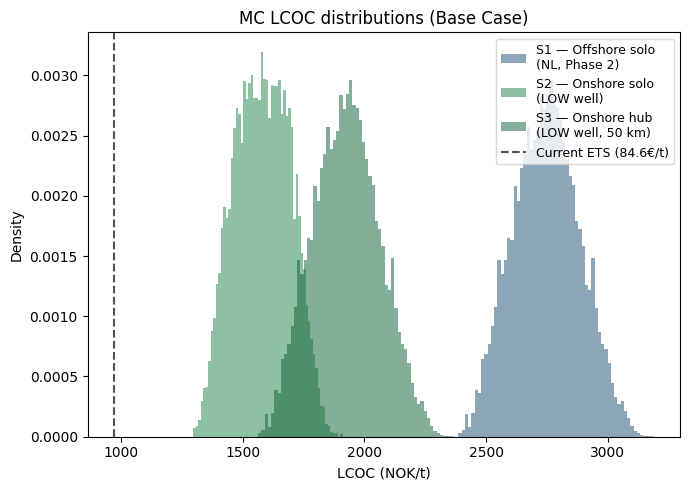

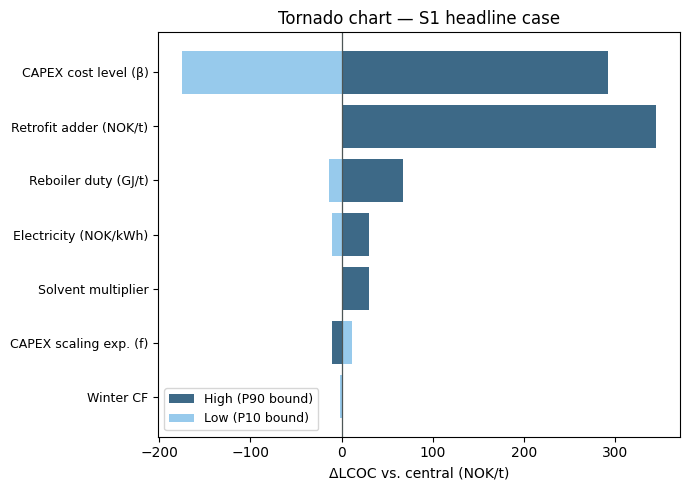

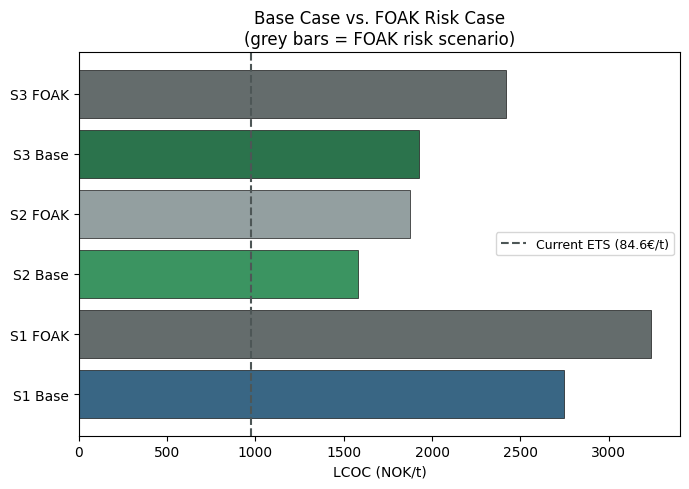

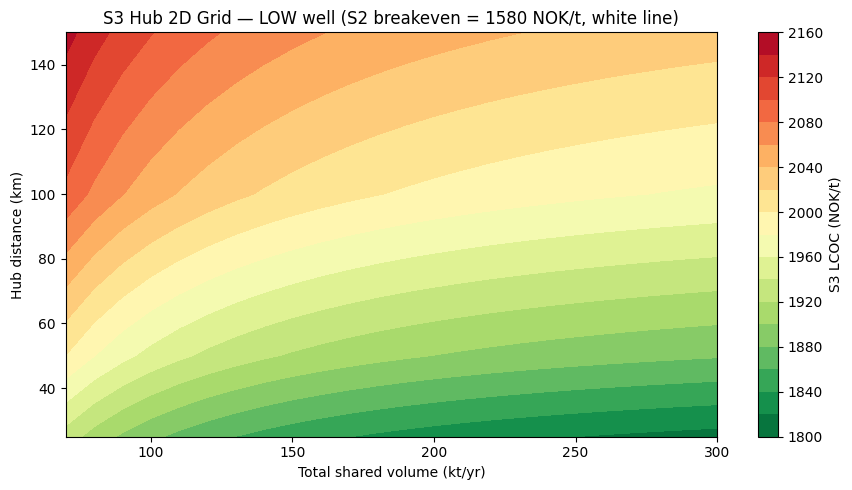

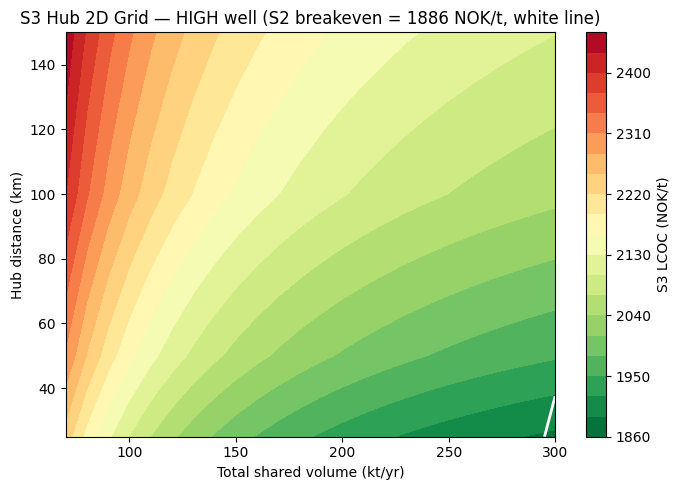

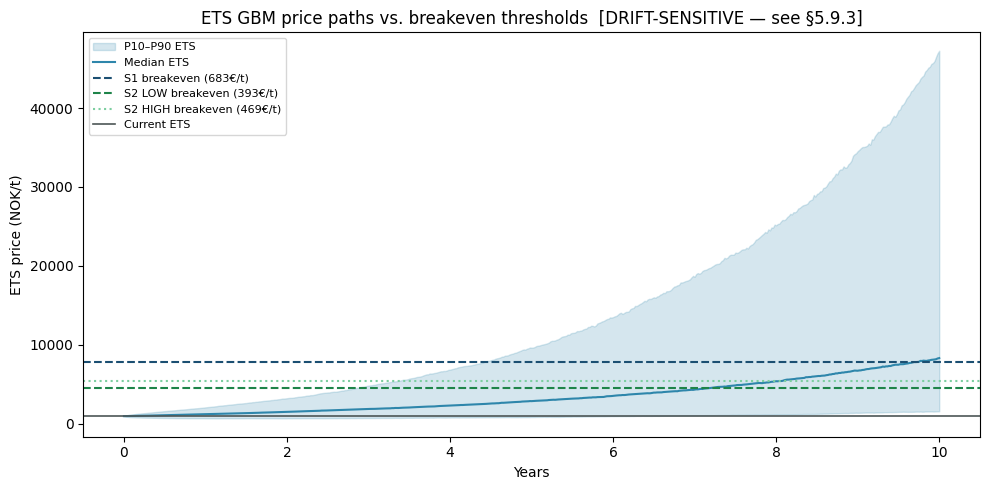

All 6 figures saved to ../outputs


In [22]:
import os
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

# ── Panel 1: MC distributions ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 5))
colours = {
    "S1":        PRIMARY_BLUE_DARK,
    "S2_LOW":    GREEN_DARK,
    "S3_LOW_50": "#0B5E31",
}
for name, col in colours.items():
    ax1.hist(mc[name], bins=60, alpha=0.5, color=col, density=True,
             label=SCENARIO_LABELS[name])
ax1.axvline(P_ETS_NOK_t, color=GREY_DARK, lw=1.5, ls="--",
            label=f"Current ETS ({P_ETS_EUR_t}€/t)")
ax1.set_xlabel("LCOC (NOK/t)"); ax1.set_ylabel("Density")
ax1.set_title("MC LCOC distributions (Base Case)"); ax1.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p1_mc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Panel 2: Tornado chart S1 ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 5))
labels_s = sorted(swings_S1, key=swings_S1.get)
lo_vals  = [oat_S1[l][0] - central_S1 for l in labels_s]
hi_vals  = [oat_S1[l][1] - central_S1 for l in labels_s]
y_pos    = np.arange(len(labels_s))
ax2.barh(y_pos, hi_vals, color=PRIMARY_BLUE_DARK,  alpha=0.85, label="High (P90 bound)")
ax2.barh(y_pos, lo_vals, color=PRIMARY_BLUE_LIGHT, alpha=0.85, label="Low (P10 bound)")
ax2.set_yticks(y_pos); ax2.set_yticklabels([l[:30] for l in labels_s], fontsize=9)
ax2.axvline(0, color=GREY_DARK, lw=0.9)
ax2.set_xlabel("ΔLCOC vs. central (NOK/t)")
ax2.set_title("Tornado chart — S1 headline case")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p2_tornado_s1.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Panel 3: Base vs FOAK ─────────────────────────────────────────────────
# Rule: Base = scenario colour; FOAK = GREY_DARK (pessimistic/risk series)
fig3, ax3 = plt.subplots(figsize=(7, 5))
configs_f = ["S1 Base", "S1 FOAK", "S2 Base", "S2 FOAK", "S3 Base", "S3 FOAK"]
means_f   = [mc["S1"].mean(),        mc_foak["S1_foak"].mean(),
             mc["S2_LOW"].mean(),     mc_foak["S2_LOW_foak"].mean(),
             mc["S3_LOW_50"].mean(),  mc_foak["S3_LOW_foak"].mean()]
cols_f    = [PRIMARY_BLUE_DARK, GREY_DARK,
             GREEN_DARK,        GREY,
             "#0B5E31",         GREY_DARK]
ax3.barh(configs_f, means_f, color=cols_f, edgecolor="black", linewidth=0.5, alpha=0.87)
ax3.axvline(P_ETS_NOK_t, color=GREY_DARK, lw=1.5, ls="--",
            label=f"Current ETS ({P_ETS_EUR_t}€/t)")
ax3.set_xlabel("LCOC (NOK/t)")
ax3.set_title("Base Case vs. FOAK Risk Case\n(grey bars = FOAK risk scenario)")
ax3.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p3_base_vs_foak.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Panel 4: S3 hub grid LOW ──────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(9, 5))
grid_mat_low = np.array([grid_low[d] for d in DISTANCES_km])
cf4 = ax4.contourf(VOLUMES_t_yr/1000, DISTANCES_km, grid_mat_low, levels=20, cmap="RdYlGn_r")
plt.colorbar(cf4, ax=ax4, label="S3 LCOC (NOK/t)")
ax4.contour(VOLUMES_t_yr/1000, DISTANCES_km,
            np.where(grid_mat_low < S2_mean_low, 1.0, 0.0),
            levels=[0.5], colors="white", linewidths=2)
ax4.set_xlabel("Total shared volume (kt/yr)"); ax4.set_ylabel("Hub distance (km)")
ax4.set_title(f"S3 Hub 2D Grid — LOW well (S2 breakeven = {S2_mean_low:.0f} NOK/t, white line)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p4_hub_grid_low.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Panel 5: S3 hub grid HIGH ─────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(7, 5))
grid_mat_high = np.array([grid_high[d] for d in DISTANCES_km])
cf5 = ax5.contourf(VOLUMES_t_yr/1000, DISTANCES_km, grid_mat_high, levels=20, cmap="RdYlGn_r")
plt.colorbar(cf5, ax=ax5, label="S3 LCOC (NOK/t)")
ax5.contour(VOLUMES_t_yr/1000, DISTANCES_km,
            np.where(grid_mat_high < S2_mean_high, 1.0, 0.0),
            levels=[0.5], colors="white", linewidths=2)
ax5.set_xlabel("Total shared volume (kt/yr)"); ax5.set_ylabel("Hub distance (km)")
ax5.set_title(f"S3 Hub 2D Grid — HIGH well (S2 breakeven = {S2_mean_high:.0f} NOK/t, white line)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p5_hub_grid_high.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Panel 6: ETS price paths + breakeven lines ────────────────────────────
fig6, ax6 = plt.subplots(figsize=(10, 5))
t_axis = np.linspace(0, 10, ETS_paths.shape[1])
pct_lo = np.percentile(ETS_paths, 10, axis=0)
pct_hi = np.percentile(ETS_paths, 90, axis=0)
pct_md = np.percentile(ETS_paths, 50, axis=0)
ax6.fill_between(t_axis, pct_lo, pct_hi, alpha=0.2, color=PRIMARY_BLUE, label="P10–P90 ETS")
ax6.plot(t_axis, pct_md, color=PRIMARY_BLUE, lw=1.5, label="Median ETS")
be_lines = {
    "S1 breakeven":     (breakeven_ETS_NOK(mc["S1"].mean(),      phi_bio_base), PRIMARY_BLUE_DARK, "--"),
    "S2 LOW breakeven": (breakeven_ETS_NOK(mc["S2_LOW"].mean(),  phi_bio_base), GREEN_DARK,        "--"),
    "S2 HIGH breakeven":(breakeven_ETS_NOK(mc["S2_HIGH"].mean(), phi_bio_base), GREEN_LIGHT,       ":"),
}
for label, (be, col, ls) in be_lines.items():
    ax6.axhline(be, color=col, ls=ls, lw=1.5, label=f"{label} ({be/EUR_NOK_2025:.0f}€/t)")
ax6.axhline(P_ETS_NOK_t, color=GREY_DARK, lw=1.2, ls="-", label="Current ETS")
ax6.set_xlabel("Years"); ax6.set_ylabel("ETS price (NOK/t)")
ax6.set_title("ETS GBM price paths vs. breakeven thresholds  [DRIFT-SENSITIVE — see §5.9.3]")
ax6.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fig_p6_ets_paths.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close()

print("All 6 figures saved to", output_dir)

### Figure 1 — Headline LCOC Comparison (all configurations, P10–P90 whiskers)

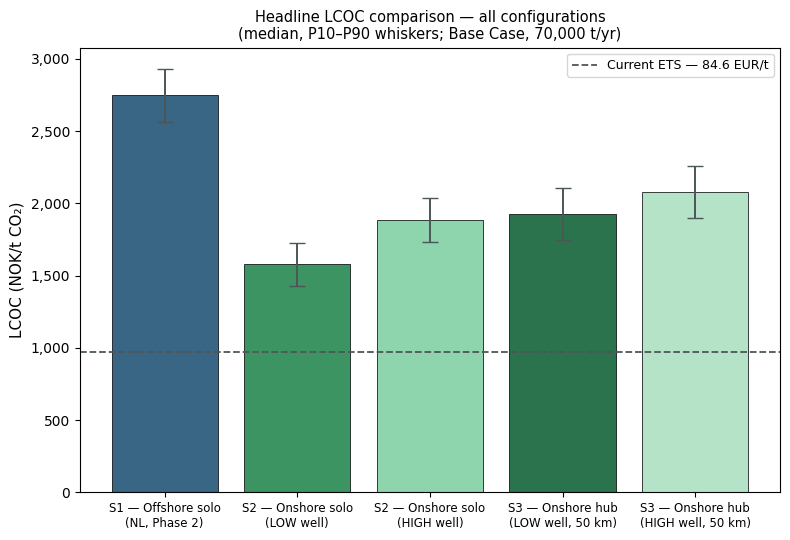

Figure 1 saved.


In [23]:
# Figure 1: Headline LCOC — all scenarios, median + P10/P90 whiskers
scenarios = list(mc.keys())
medians  = [np.percentile(mc[s], 50) for s in scenarios]
p10s     = [np.percentile(mc[s], 10) for s in scenarios]
p90s     = [np.percentile(mc[s], 90) for s in scenarios]
errs_lo  = [medians[i] - p10s[i] for i in range(len(scenarios))]
errs_hi  = [p90s[i] - medians[i] for i in range(len(scenarios))]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(range(len(scenarios)), medians,
       color=[SCENARIO_COLORS[s] for s in scenarios],
       yerr=[errs_lo, errs_hi], capsize=6, alpha=0.87,
       edgecolor="black", linewidth=0.6,
       error_kw=dict(elinewidth=1.4, ecolor=GREY_DARK))
ax.axhline(P_ETS_NOK_t, color=GREY_DARK, linestyle="--", linewidth=1.3,
           label=f"Current ETS — {P_ETS_EUR_t} EUR/t")
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios], fontsize=8.5)
ax.set_ylabel("LCOC (NOK/t CO₂)", fontsize=11)
ax.set_title(
    "Headline LCOC comparison — all configurations\n"
    "(median, P10–P90 whiskers; Base Case, 70,000 t/yr)",
    fontsize=10.5)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("fig01_headline_lcoc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

### Figure 2 — Biogenic Disconnect (LCOC vs Breakeven ETS by φ_bio)

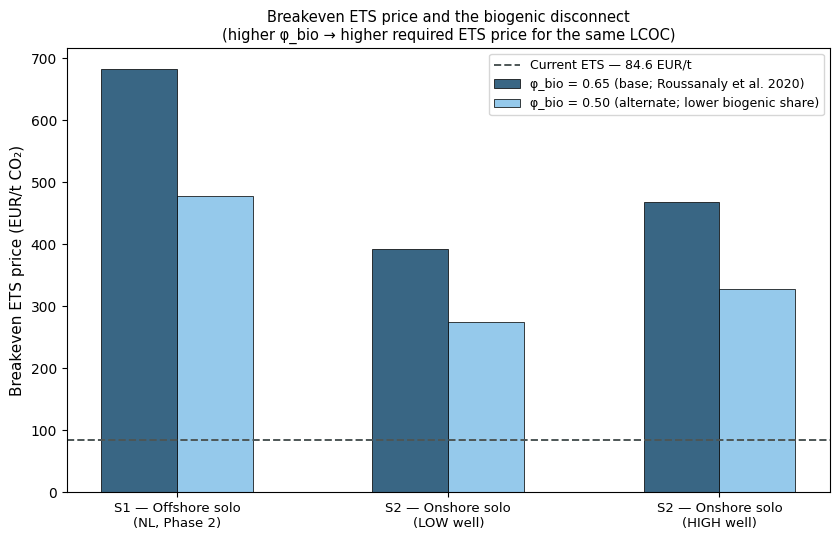

Figure 2 saved.


In [24]:
# Figure 2: LCOC vs breakeven ETS — the biogenic disconnect
# Focus on S1, S2_LOW, S2_HIGH (the three headline cases for policy discussion)
headline = ["S1", "S2_LOW", "S2_HIGH"]
x = np.arange(len(headline))
width = 0.28

fig, ax = plt.subplots(figsize=(8.5, 5.5))

phi_styles = [
    ("base", PRIMARY_BLUE_DARK, "φ_bio = 0.65 (base; Roussanaly et al. 2020)"),
    ("alt",  PRIMARY_BLUE_LIGHT, "φ_bio = 0.50 (alternate; lower biogenic share)"),
]

for i, (phi_label, color, legend_label) in enumerate(phi_styles):
    phi = phi_bio[phi_label]
    be_vals_eur = [breakeven_ETS_NOK(mc[s].mean(), phi) / EUR_NOK_2025 for s in headline]
    ax.bar(x + (i - 0.5) * width, be_vals_eur, width,
           label=legend_label, color=color, alpha=0.87,
           edgecolor="black", linewidth=0.6)

ax.axhline(P_ETS_EUR_t, color=GREY_DARK, linestyle="--", linewidth=1.4,
           label=f"Current ETS — {P_ETS_EUR_t} EUR/t")
ax.set_xticks(x)
ax.set_xticklabels([SCENARIO_LABELS[s] for s in headline], fontsize=9.5)
ax.set_ylabel("Breakeven ETS price (EUR/t CO₂)", fontsize=11)
ax.set_title(
    "Breakeven ETS price and the biogenic disconnect\n"
    "(higher φ_bio → higher required ETS price for the same LCOC)",
    fontsize=10.5)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("fig02_biogenic_disconnect.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

### Figure 3 — Base Case vs FOAK Risk Case (Becattini 2024 format)

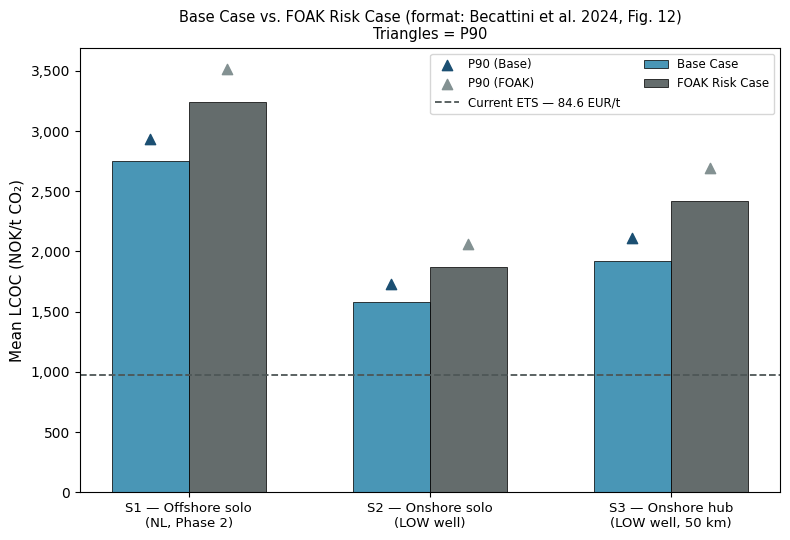

Figure 3 saved.


In [25]:
# Figure 3: Base Case vs FOAK Risk Case (format: Becattini et al. 2024, Fig. 12)
# mc_foak keys: S1_foak, S2_LOW_foak, S3_LOW_foak
foak_map = [
    ("S1",        "S1_foak",     "S1 — Offshore solo\n(NL, Phase 2)"),
    ("S2_LOW",    "S2_LOW_foak", "S2 — Onshore solo\n(LOW well)"),
    ("S3_LOW_50", "S3_LOW_foak", "S3 — Onshore hub\n(LOW well, 50 km)"),
]

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(foak_map))
width = 0.32

base_vals = [mc[base].mean()      for base, _, _ in foak_map]
foak_vals = [mc_foak[foak].mean() for _, foak, _ in foak_map]
base_p90  = [np.percentile(mc[base], 90)       for base, _, _ in foak_map]
foak_p90  = [np.percentile(mc_foak[foak], 90)  for _, foak, _ in foak_map]

ax.bar(x - width/2, base_vals, width, label="Base Case",
       color=PRIMARY_BLUE, alpha=0.87, edgecolor="black", linewidth=0.6)
ax.bar(x + width/2, foak_vals, width, label="FOAK Risk Case",
       color=GREY_DARK, alpha=0.87, edgecolor="black", linewidth=0.6)
# P90 markers
ax.scatter(x - width/2, base_p90, marker="^", color=PRIMARY_BLUE_DARK,
           zorder=5, s=55, label="P90 (Base)")
ax.scatter(x + width/2, foak_p90, marker="^", color=GREY,
           zorder=5, s=55, label="P90 (FOAK)")
ax.axhline(P_ETS_NOK_t, color=GREY_DARK, linestyle="--", linewidth=1.3,
           label=f"Current ETS — {P_ETS_EUR_t} EUR/t")
ax.set_xticks(x)
ax.set_xticklabels([lbl for _, _, lbl in foak_map], fontsize=9.5)
ax.set_ylabel("Mean LCOC (NOK/t CO₂)", fontsize=11)
ax.set_title("Base Case vs. FOAK Risk Case (format: Becattini et al. 2024, Fig. 12)\n"
             "Triangles = P90", fontsize=10.5)
ax.legend(fontsize=8.5, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("fig03_base_vs_foak.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

### Figure 4 — Heat-Pump Configuration vs LCOC

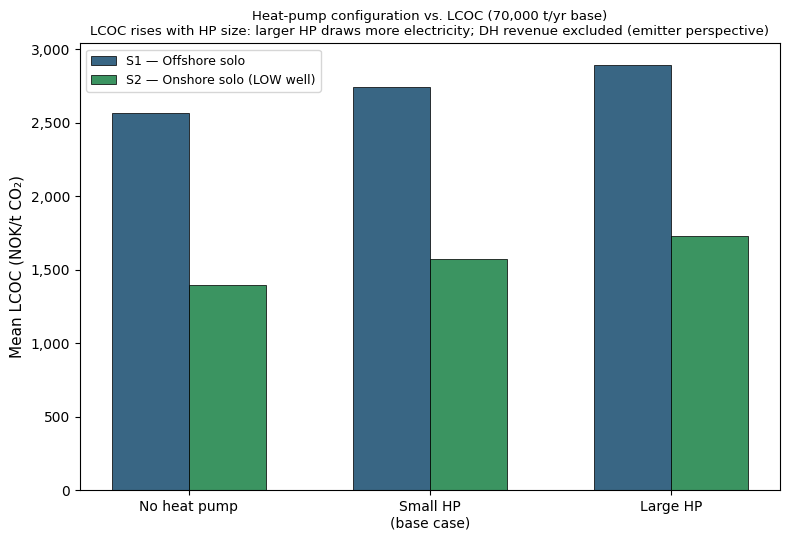

Figure 4 saved.


In [26]:
# Figure 4: Heat-pump configuration vs LCOC (all headline scenarios)
# mc_hp keys: {none,small,large}_{S1,S2}
hp_labels = {"none": "No heat pump", "small": "Small HP\n(base case)", "large": "Large HP"}
sc_pairs  = [("S1", PRIMARY_BLUE_DARK, "S1 — Offshore solo"),
             ("S2",  GREEN_DARK,        "S2 — Onshore solo (LOW well)")]

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(3)
width = 0.32

for i, (sc, color, label) in enumerate(sc_pairs):
    vals = [mc_hp[f"{hp}_{sc}"].mean() for hp in ("none", "small", "large")]
    ax.bar(x + (i - 0.5) * width, vals, width,
           label=label, color=color, alpha=0.87,
           edgecolor="black", linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels([hp_labels[h] for h in ("none","small","large")], fontsize=10)
ax.set_ylabel("Mean LCOC (NOK/t CO₂)", fontsize=11)
ax.set_title("Heat-pump configuration vs. LCOC (70,000 t/yr base)\n"
             "LCOC rises with HP size: larger HP draws more electricity; "
             "DH revenue excluded (emitter perspective)", fontsize=9.5)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("fig04_heat_pump.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

### Figure 5 — Design Capacity Scenarios A / B / C

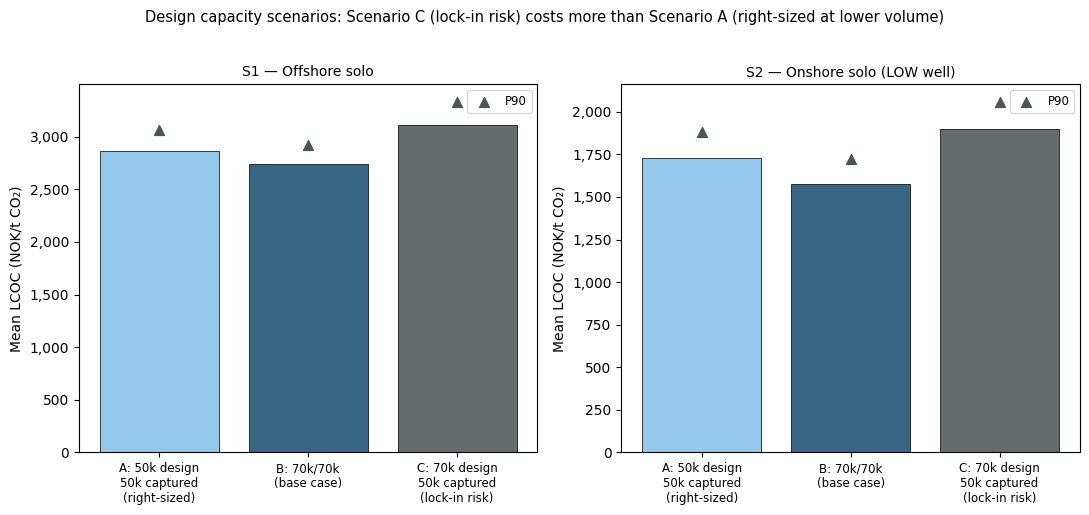

Figure 5 saved.


In [27]:
# Figure 5: Design capacity scenarios A / B / C
# mc_cap keys: {A,B,C}_{S1,S2_LOW}
dc_labels = {
    "A": "A: 50k design\n50k captured\n(right-sized)",
    "B": "B: 70k/70k\n(base case)",
    "C": "C: 70k design\n50k captured\n(lock-in risk)",
}
dc_colors = [PRIMARY_BLUE_LIGHT, PRIMARY_BLUE_DARK, GREY_DARK]
sc_list   = [("S1",     "S1 — Offshore solo"),
             ("S2_LOW", "S2 — Onshore solo (LOW well)")]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (sc_key, sc_label) in zip(axes, sc_list):
    vals = [mc_cap[f"{sc}_{sc_key}"].mean() for sc in ["A","B","C"]]
    p90s = [np.percentile(mc_cap[f"{sc}_{sc_key}"], 90) for sc in ["A","B","C"]]
    bars = ax.bar(range(3), vals, color=dc_colors, alpha=0.87,
                  edgecolor="black", linewidth=0.6)
    ax.scatter(range(3), p90s, marker="^", color=GREY_DARK,
               zorder=5, s=50, label="P90")
    ax.set_xticks(range(3))
    ax.set_xticklabels([dc_labels[s] for s in ["A","B","C"]], fontsize=8.5)
    ax.set_ylabel("Mean LCOC (NOK/t CO₂)", fontsize=10)
    ax.set_title(sc_label, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(fontsize=8.5)

fig.suptitle(
    "Design capacity scenarios: Scenario C (lock-in risk) costs more than Scenario A (right-sized at lower volume)",
    fontsize=10.5, y=1.02)
plt.tight_layout()
plt.savefig("fig05_design_capacity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

### Figure 6 — Spearman Rank Correlation (Sensitivity Indices, S1)

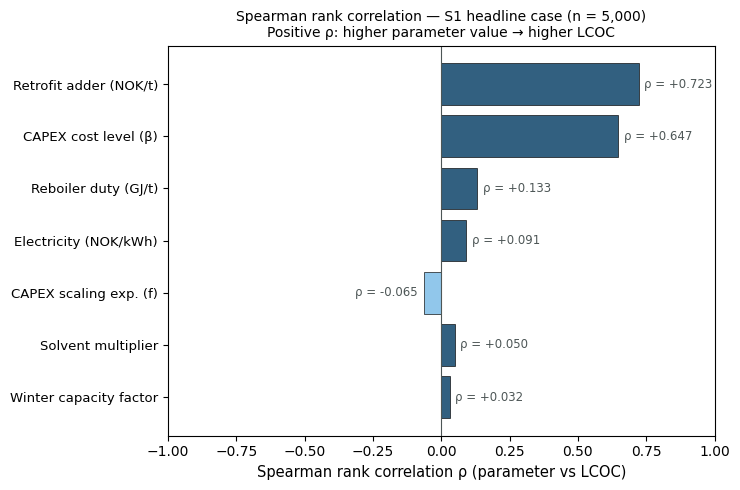

Figure 6 saved.


In [28]:
# Figure 6: Spearman rank correlation — parameter → LCOC output (S1)
# Re-draw MC with saved parameter arrays to compute rank correlations.
np.random.seed(42)
n_sp = 5000
f_sp  = np.random.uniform(f_scale_lo, f_scale_hi, n_sp)
bt_sp = sample_beta_cost_mult(n_sp)
cf_sp = np.random.uniform(CF_winter_lo, CF_winter_hi, n_sp)
rd_sp = np.random.triangular(RD_min, RD_mode, RD_max, n_sp)
re_sp = np.random.uniform(RETRO_LO_NOK_t, RETRO_HI_NOK_t, n_sp)
sl_sp = np.random.uniform(SOLV_MULT_LO, SOLV_MULT_HI, n_sp)
el_sp = draw_levelised_electricity_prices_ou(n_sp, seed=3042)

lcoc_sp = np.array([
    compute_LCOC(
        Q_design_cap=70_000, Q_captured=70_000,
        x_CO2_frac=x_CO2_base, CF_winter=cf_sp[i],
        q_reboiler=rd_sp[i], steam_NOK_GJ=steam_annual_NOK_GJ,
        elec_NOK_kWh=el_sp[i], f_exp=f_sp[i],
        beta_mult=bt_sp[i], retrofit_adder=re_sp[i],
        solvent_mult=sl_sp[i],
        scenario="S1", hp_config="small", NL_phase=2)
    for i in range(n_sp)
])

param_pairs = [
    ("CAPEX cost level (β)",     bt_sp),
    ("CAPEX scaling exp. (f)",   f_sp),
    ("Electricity (NOK/kWh)",    el_sp),
    ("Reboiler duty (GJ/t)",     rd_sp),
    ("Winter capacity factor",   cf_sp),
    ("Retrofit adder (NOK/t)",   re_sp),
    ("Solvent multiplier",       sl_sp),
]

rhos = {lbl: float(spearmanr(arr, lcoc_sp).statistic) for lbl, arr in param_pairs}
sorted_rhos = sorted(rhos.items(), key=lambda kv: abs(kv[1]))

labels_sorted = [k for k, _ in sorted_rhos]
vals_sorted   = [v for _, v in sorted_rhos]
colors_sorted = [PRIMARY_BLUE_DARK if v > 0 else PRIMARY_BLUE_LIGHT for v in vals_sorted]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(range(len(labels_sorted)), vals_sorted, color=colors_sorted,
        edgecolor="black", linewidth=0.5, alpha=0.9)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=9.5)
ax.axvline(0, color=GREY_DARK, linewidth=0.8)
ax.set_xlabel("Spearman rank correlation ρ (parameter vs LCOC)", fontsize=10.5)
ax.set_title("Spearman rank correlation — S1 headline case (n = 5,000)\n"
             "Positive ρ: higher parameter value → higher LCOC", fontsize=10)
ax.set_xlim(-1, 1)
# Add ρ value labels
for i, v in enumerate(vals_sorted):
    ax.text(v + 0.02 * np.sign(v), i, f"ρ = {v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5, color=GREY_DARK)
plt.tight_layout()
plt.savefig("fig06_spearman.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

### Figure 7 — Pedigree-vs-Sensitivity Diagnostic (van der Spek 2020 format)

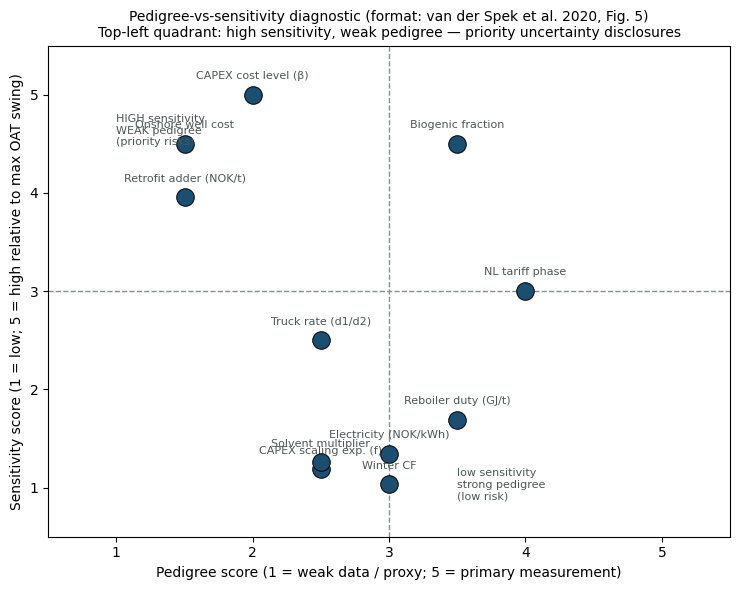

Figure 7 saved.


In [29]:
# Figure 7: Pedigree-vs-sensitivity diagnostic (format: van der Spek et al. 2020, Fig. 5)
# Sensitivity score (1-5): derived from OAT swing relative to maximum swing.
# Pedigree score (1-5): expert-assigned data quality rating per van der Spek 2020 criteria.
# Both scales: 5 = highest (most sensitive / strongest pedigree).

# OAT swing-based sensitivity scores for S1 (already computed in cell 33)
max_swing = max(swings_S1.values())
oat_sens_score = {k: 1 + 4 * (v / max_swing) for k, v in swings_S1.items()}

pedigree_data = {
    # parameter:                  (sens_score derived from OAT,  pedigree 1-5)
    "CAPEX cost level (β)":       (oat_sens_score.get("CAPEX cost level (β)", 5.0),        2.0),
    "CAPEX scaling exp. (f)":     (oat_sens_score.get("CAPEX scaling exp. (f)", 4.0),      2.5),
    "Electricity (NOK/kWh)":      (oat_sens_score.get("Electricity (NOK/kWh)", 3.0),       3.0),
    "Reboiler duty (GJ/t)":       (oat_sens_score.get("Reboiler duty (GJ/t)", 3.5),        3.5),
    "Winter CF":                  (oat_sens_score.get("Winter CF", 2.0),                   3.0),
    "Retrofit adder (NOK/t)":     (oat_sens_score.get("Retrofit adder (NOK/t)", 2.5),      1.5),
    "Solvent multiplier":         (oat_sens_score.get("Solvent multiplier", 2.0),           2.5),
    # Fixed structural parameters (not in OAT sweep; placed by expert judgment)
    "Onshore well cost":          (4.5,  1.5),   # large utilisation-scale sensitivity; single proxy source
    "Biogenic fraction":          (4.5,  3.5),   # drives breakeven price; Roussanaly et al. 2020 cited
    "NL tariff phase":            (3.0,  4.0),   # Gassnova (2025) official; phase uncertainty disclosed
    "Truck rate (d1/d2)":         (2.5,  2.5),   # Halsfund/Stolaroff converge; beyond-range proxy
}

# Stagger labels that share the same (sens, ped) coordinates to avoid overlap
from collections import defaultdict
coord_count = defaultdict(int)

fig, ax = plt.subplots(figsize=(7.5, 6))
for label, (sens, ped) in pedigree_data.items():
    ax.scatter(ped, sens, s=160, color=PRIMARY_BLUE_DARK,
               edgecolor="black", linewidth=0.7, zorder=3)
    # Vertical jitter for overlapping labels
    key = (round(sens, 1), round(ped, 1))
    offset = 0.18 * coord_count[key]
    coord_count[key] += 1
    ax.annotate(label, (ped, sens + offset + 0.14), fontsize=8,
                ha="center", va="bottom", color=GREY_DARK)

ax.axvline(3, color=GREY, linestyle="--", linewidth=1)
ax.axhline(3, color=GREY, linestyle="--", linewidth=1)
ax.set_xlim(0.5, 5.5);  ax.set_ylim(0.5, 5.5)
ax.set_xlabel("Pedigree score (1 = weak data / proxy; 5 = primary measurement)", fontsize=10)
ax.set_ylabel("Sensitivity score (1 = low; 5 = high relative to max OAT swing)", fontsize=10)
ax.set_title("Pedigree-vs-sensitivity diagnostic (format: van der Spek et al. 2020, Fig. 5)\n"
             "Top-left quadrant: high sensitivity, weak pedigree — priority uncertainty disclosures", fontsize=10)
ax.text(1.0, 4.8, "HIGH sensitivity\nWEAK pedigree\n(priority risks)", fontsize=8, color=GREY_DARK, va="top")
ax.text(3.5, 1.2, "low sensitivity\nstrong pedigree\n(low risk)", fontsize=8, color=GREY_DARK, va="top")
plt.tight_layout()
plt.savefig("fig07_pedigree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

### Figure 8 — S1 Transport Routing Map

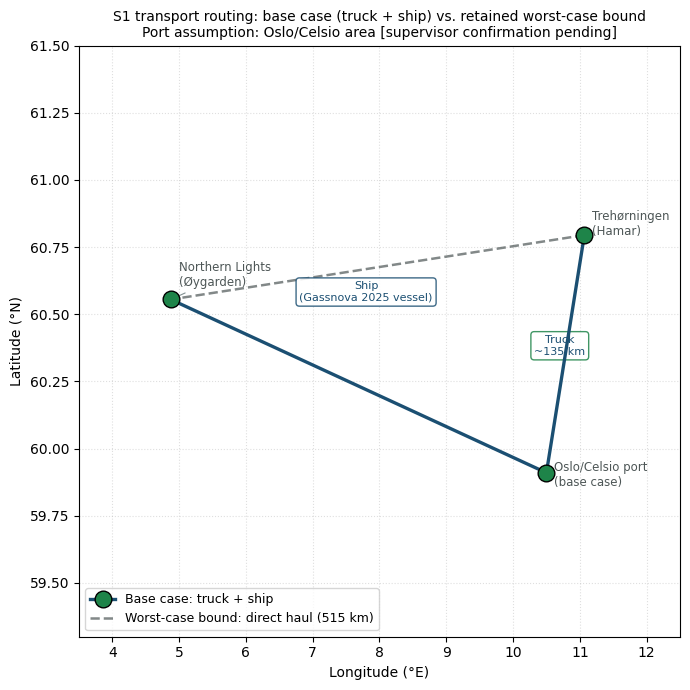

Figure 8 saved.


In [30]:
# Figure 8: S1 transport routing map — base case (truck+ship) vs. worst-case direct haul
# Coordinates are approximate (WGS84); visual schematic, not navigation-grade.
HAMAR_COORD   = (60.7945,  11.0680)   # Trehørningen Energisentral, Hamar
PORT_COORD    = (59.91,    10.50)     # Oslo/Celsio area (base-case port assumption)
OYGARDEN_COORD= (60.555,    4.875)   # Northern Lights receiving terminal, Øygarden

fig, ax = plt.subplots(figsize=(7, 7))

# Base case: Hamar → Port (truck) → Øygarden (ship)
base_lats = [HAMAR_COORD[0], PORT_COORD[0], OYGARDEN_COORD[0]]
base_lons = [HAMAR_COORD[1], PORT_COORD[1], OYGARDEN_COORD[1]]
ax.plot(base_lons, base_lats, color=PRIMARY_BLUE_DARK, linewidth=2.4,
        marker="o", markersize=12, markerfacecolor=GREEN_DARK,
        markeredgecolor="black", zorder=4, label="Base case: truck + ship")

# Worst-case bound: Hamar → Øygarden direct haul
direct_lats = [HAMAR_COORD[0], OYGARDEN_COORD[0]]
direct_lons = [HAMAR_COORD[1], OYGARDEN_COORD[1]]
ax.plot(direct_lons, direct_lats, color=GREY_DARK, linewidth=1.8,
        linestyle="--", alpha=0.7, zorder=2,
        label=f"Worst-case bound: direct haul ({DIST_DIRECT_km} km)")

# Annotations
for name, (lat, lon), offset in [
    ("Trehørningen\n(Hamar)",         HAMAR_COORD,    (0.12, 0.0)),
    ("Oslo/Celsio port\n(base case)", PORT_COORD,     (0.12, -0.05)),
    ("Northern Lights\n(Øygarden)",   OYGARDEN_COORD, (0.12, 0.05)),
]:
    ax.annotate(name, xy=(lon, lat), xytext=(lon+offset[0], lat+offset[1]),
                fontsize=8.5, color=GREY_DARK,
                arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

# Labels for route segments
ax.text(10.7, 60.35, f"Truck\n~{DIST_TRUCK_S1_km} km", fontsize=8,
        color=PRIMARY_BLUE_DARK, ha="center",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=GREEN_DARK, alpha=0.85))
ax.text(7.8, 60.55, "Ship\n(Gassnova 2025 vessel)", fontsize=8,
        color=PRIMARY_BLUE_DARK, ha="center",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=PRIMARY_BLUE_DARK, alpha=0.85))

ax.set_xlim(3.5, 12.5); ax.set_ylim(59.3, 61.5)
ax.set_xlabel("Longitude (°E)", fontsize=10); ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.set_title("S1 transport routing: base case (truck + ship) vs. retained worst-case bound\n"
             "Port assumption: Oslo/Celsio area [supervisor confirmation pending]", fontsize=10)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("fig08_routing_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 8 saved.")

### Figure 9 — Transport Rate ±50% OAT Sensitivity (Standalone)

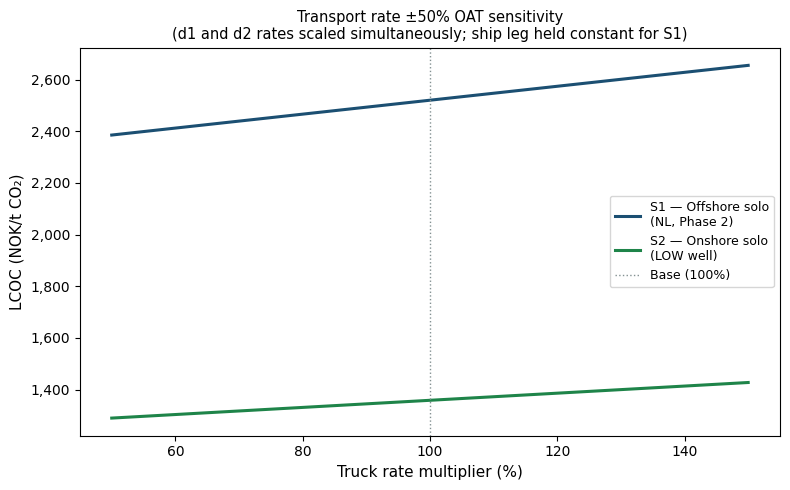

Figure 9 saved.


In [31]:
# Figure 9: Transport rate ±50% OAT sensitivity (supervisor feedback item)
# Sweeps d1/d2 truck rates simultaneously (same multiplier) for S1 and S2_LOW.
mults = np.linspace(0.5, 1.5, 25)
transport_sens = {}

for sc, well_kw in [("S1", {}), ("S2_LOW", {"well_case": "LOW"})]:
    scenario_str = "S1" if sc == "S1" else "S2"
    vals = []
    for m in mults:
        d1_t = m * d1_NOK_t_km
        d2_t = m * d2_NOK_t_km
        dist = DIST_TRUCK_S1_km if sc == "S1" else 50.0  # hub proxy 50 km for S2
        # Compute truck cost at scaled rates
        if dist <= 75:
            tc = d1_t * dist
        else:
            tc = d1_t * 75 + d2_t * (dist - 75)
        # Ship leg only for S1
        ship_leg = ship_NOK_t(Q_captured_base) if sc == "S1" else 0.0
        # Base transport (central rates)
        if dist <= 75:
            tc_base = d1_NOK_t_km * dist
        else:
            tc_base = d1_NOK_t_km * 75 + d2_NOK_t_km * (dist - 75)
        transport_base = tc_base + ship_leg
        transport_new  = tc    + ship_leg
        # Adjust central LCOC by delta
        central_lcoc = compute_LCOC(
            Q_design_cap=70_000, Q_captured=70_000,
            x_CO2_frac=x_CO2_base, CF_winter=CF_winter_central,
            q_reboiler=RD_central, steam_NOK_GJ=steam_annual_NOK_GJ,
            elec_NOK_kWh=elec_price_NOK_kWh_central,
            f_exp=f_scale_central, beta_mult=1.0,
            retrofit_adder=0.0, solvent_mult=1.0,
            scenario=scenario_str, hp_config="small",
            NL_phase=2, **well_kw)
        vals.append(central_lcoc + (transport_new - transport_base))
    transport_sens[sc] = np.array(vals)

fig, ax = plt.subplots(figsize=(8, 5))
for sc, color, label in [("S1", PRIMARY_BLUE_DARK, SCENARIO_LABELS["S1"]),
                          ("S2_LOW", GREEN_DARK,    SCENARIO_LABELS["S2_LOW"])]:
    ax.plot(mults * 100, transport_sens[sc], color=color, linewidth=2.2, label=label)

ax.axvline(100, color=GREY, linewidth=1, linestyle=":", label="Base (100%)")
ax.set_xlabel("Truck rate multiplier (%)", fontsize=11)
ax.set_ylabel("LCOC (NOK/t CO₂)", fontsize=11)
ax.set_title("Transport rate ±50% OAT sensitivity\n"
             "(d1 and d2 rates scaled simultaneously; ship leg held constant for S1)", fontsize=10.5)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("fig09_transport_rate_oat.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 9 saved.")

## 21. Results Summary Tables

In [32]:
print("=" * 80)
print("TABLE 6.1 — HEADLINE LCOC (MC Mean, P10, P50, P90; Base Case, LOW well)")
print("=" * 80)
for name, arr in mc.items():
    p10, p50, p90 = np.percentile(arr, [10, 50, 90])
    print(f"  {name:22s}  Mean={arr.mean():,.0f}  P10={p10:,.0f}  P50={p50:,.0f}  P90={p90:,.0f}  Std={arr.std():,.0f}")

print()
print("TABLE 6.2 — FOAK RISK CASE")
for name, arr in mc_foak.items():
    p10, p50, p90 = np.percentile(arr, [10, 50, 90])
    print(f"  {name:22s}  Mean={arr.mean():,.0f}  P10={p10:,.0f}  P50={p50:,.0f}  P90={p90:,.0f}")

print()
print("TABLE 6.3 — PAIRWISE COMPARISON PROBABILITIES (CRN)")
for label, a, b in pairs:
    print(f"  P({label}): {np.mean(a < b):.3f}")

print()
print("TABLE 6.4 — BREAKEVEN ETS PRICE (NOK/t and EUR/t; base φ_bio=0.65)")
for name, arr in mc.items():
    be_NOK = breakeven_ETS_NOK(arr.mean(), phi_bio_base)
    print(f"  {name:22s}  NOK {be_NOK:,.0f}/t = EUR {be_NOK/EUR_NOK_2025:,.0f}/t")

print()
print("TABLE 6.5 — NL PHASE SENSITIVITY (S1 only)")
print(f"  Phase 1: {nl_tariff_NOK_t(1):.0f} NOK/t = {nl_tariff_NOK_t(1)/EUR_NOK_2025:.0f} EUR/t")
print(f"  Phase 2: {nl_tariff_NOK_t(2):.0f} NOK/t = {nl_tariff_NOK_t(2)/EUR_NOK_2025:.0f} EUR/t")

print()
print("TABLE 6.6 — HUB 2D GRID SUMMARY")
print(f"  S3 LOW:  outperforms S2 LOW  in {cnt_low}/{total_cells} ({cnt_low/total_cells*100:.0f}%) cells")
print(f"  S3 HIGH: outperforms S2 HIGH in {cnt_high}/{total_cells} ({cnt_high/total_cells*100:.0f}%) cells")

print()
print("TABLE 6.7 — REQUIRED CAPEX GRANT")
print("  Finding: OPEX alone exceeds ETS revenue for all configurations at today's price.")
print("  No finite CAPEX grant closes the gap — OPEX-side support or higher carbon price required.")
print(f"  (OPEX floor > ETS revenue of {P_ETS_NOK_t:.0f} NOK/t × {1-phi_bio_base:.2f} = {P_ETS_NOK_t*(1-phi_bio_base):.0f} NOK/t)")

print()
print("TABLE 6.8 — TRANSPORT RATE ±50% SENSITIVITY")
for mult_label, mult in [("-50%", 0.5), ("Base", 1.0), ("+50%", 1.5)]:
    tr = mult*d1_NOK_t_km*75 + mult*d2_NOK_t_km*(DIST_TRUCK_S1_km-75) + ship_NOK_t(Q_captured_base)
    delta = tr - (truck_cost_NOK_t(DIST_TRUCK_S1_km) + ship_NOK_t(Q_captured_base))
    print(f"  S1 truck {mult_label}: transport={tr:.0f} NOK/t  ΔLCOC≈{delta:+.0f}")

TABLE 6.1 — HEADLINE LCOC (MC Mean, P10, P50, P90; Base Case, LOW well)
  S1                      Mean=2,748  P10=2,566  P50=2,747  P90=2,931  Std=136
  S2_LOW                  Mean=1,580  P10=1,429  P50=1,581  P90=1,729  Std=113
  S2_HIGH                 Mean=1,886  P10=1,735  P50=1,886  P90=2,035  Std=113
  S3_LOW_50               Mean=1,925  P10=1,743  P50=1,925  P90=2,109  Std=136
  S3_HIGH_50              Mean=2,078  P10=1,896  P50=2,078  P90=2,262  Std=136

TABLE 6.2 — FOAK RISK CASE
  S1_foak                 Mean=3,242  P10=2,992  P50=3,232  P90=3,516
  S2_LOW_foak             Mean=1,874  P10=1,694  P50=1,870  P90=2,059
  S3_LOW_foak             Mean=2,419  P10=2,169  P50=2,409  P90=2,694

TABLE 6.3 — PAIRWISE COMPARISON PROBABILITIES (CRN)
  P(S2_LOW  < S1): 1.000
  P(S2_HIGH < S1): 1.000
  P(S3_LOW  < S1): 1.000
  P(S3_HIGH < S1): 1.000
  P(S3_LOW  < S2_LOW): 0.000
  P(S3_HIGH < S2_HIGH): 0.000

TABLE 6.4 — BREAKEVEN ETS PRICE (NOK/t and EUR/t; base φ_bio=0.65)
  S1           

## 22. Version Notes

**v7 (corrected) — changes from prior v7:**

| Issue | Previous | Corrected |
|---|---|---|
| TEC→TOC multiplier | 2.27× base / 3.81× FOAK (wrong compounding) | 1.85× base / 2.50× FOAK (additive contingency on EPC) |
| Reboiler duty in MC | Hardcoded RD_central always | Sampled Triangular(3.58,3.70,4.30) wired into steam cost |
| FOAK ramp-up | Contingency only; no ramp-up in LCOC | Rubin Eq. C10 levelised CF in LCOC denominator |
| Scenario C CAPEX | Q_captured used for TEC sizing | Q_design_cap used for TEC and liquefaction; Q_captured for OPEX |
| Electricity price process | OU calibrated after MC; MC used clipped Normal draw | OU calibrated before MC; each iteration uses discounted levelised OU electricity price |
| Heat pump CAPEX | Computed but not added to TOC | Added to TOC_total |
| S2 compression OPEX | Missing | 95 kWh/t added |
| NL storage denominator | 1.5 Mt/yr (wrong) | 5 Mt/yr (correct design capacity) |
| Pairwise MC comparison | Independent draws (noisy) | CRN — same draws for S1/S2/S3 |
| Solvent baseline | Undocumented `×50` | NOK 60/t documented (Nwaoha et al. 2018) |
| Liq. reference scale | Undocumented 100k | Documented: Returkraft/KAN (2025) |
| Grid MC samples | 200 per cell | 500 per cell |
| Sensitivity analysis | Missing | OAT tornado + Spearman rank correlation added |
| Required grant | Missing | Added (reports OPEX-dominated finding) |
| Structural scenario sweeps | Missing | A/B/C, concentration, biogenic, heat pump, Eliasson, NL phase added |

**Data files needed (update paths in Section 18):**
- `EU_ETS_Phase4_prices.csv` — columns: date, price_EUR_t
- `NO1_electricity_prices.csv` — columns: date, price_NOK_kWh
